# Detecting and Separating Adjacent Scoria Cones from DEMs

**Course:** Computational Vision — UniGe<br>
**Student:** Gabriele Berruti (4791919)

**Goal.** Detect scoria cones from single-channel Digital Elevation Models (DEMs).<br>
**Distinctive contribution.** Separate *nested / adjacent* cones that point-based blob detectors merge into a single detection, via a watershed segmentation of the crater depressions.

**Datasets:**<br>
*El Hierro*: 5 m, with ground truth (development / validation).<br>
*Jeju*: 10 m, no ground truth (qualitative / unsupervised).<br>
*Etna*: 2 m --- only loaded and inspected in Step 0; **not used** in any later step.

---

## Step 0 — DEM loading and inspection

The raw DEM is a single-channel raster whose pixel value is an elevation in metres (a
*range image*, cf. slide deck `04_3Dvision_small` p.3). <br>
Before any analysis we open each
DEM, convert the dataset-specific *nodata* sentinel to `NaN`, and inspect shape,
resolution, dtype and elevation range.

*Test:* resolutions must come out as 2 / 5 / 10 m and the max elevations must match the
real volcanoes (Etna ~3.3 km, El Hierro ~1.5 km, Jeju/Hallasan ~1.95 km).

In [1]:
import numpy as np
import rasterio
from pathlib import Path

DATA_DIR = Path("..") / "CinderConesDataPack"

DEM_PATHS = {
    "El Hierro": DATA_DIR / "ElHierro/DEM/dem5m/Hierro.tif",
    "Etna":      DATA_DIR / "Etna/DEM2m/DEM 2 m Etna-001.tif",
    "Jeju":      DATA_DIR / "Jeju/Dem10m/Raster Jeju 5k.tif",
}

def load_dem(path):
    """Load a georeferenced DEM; nodata -> NaN. Returns (dem, res, crs)."""
    with rasterio.open(path) as src:
        dem = src.read(1, masked=True).filled(np.nan).astype(np.float32)
        res, crs = src.res, src.crs
    return dem, res, crs

**Column legend.**<br>
*dataset*: study area.<br>
*H × W*: raster height × width in pixels (matrix rows × columns).<br>
*Mpx*: total number of pixels in millions (H·W), a proxy for the memory footprint.<br>
*NaN%*: share of pixels that were *nodata* and got mapped to `NaN` (terrain outside the raster/island, ignored by every later step).<br>
*res(m)*: spatial resolution, i.e. the ground size of a single pixel in metres.<br>
*dtype*: numeric type of the elevation values.<br>
*z_max(m)*: maximum elevation in metres, used as a sanity check against the real volcano.

In [2]:
hdr = f"{'dataset':10} {'H x W':>15} {'Mpx':>7} {'NaN%':>6} {'res(m)':>7} {'dtype':>8} {'z_max(m)':>9}"
print(hdr); print("-" * len(hdr))
for name, path in DEM_PATHS.items():
    dem, res, crs = load_dem(path)
    H, W = dem.shape
    nan_pct = 100 * np.isnan(dem).sum() / dem.size
    zmax = np.nanmax(dem)
    print(f"{name:10} {f'{H} x {W}':>15} {H*W/1e6:7.1f} {nan_pct:5.0f}% {res[0]:7.1f} "
          f"{str(dem.dtype):>8} {zmax:9.1f}")

# single-channel proof on El Hierro: one raster band, one scalar (elevation in m) per pixel
dem_h0, _, _ = load_dem(DEM_PATHS['El Hierro'])
r, c = dem_h0.shape[0] // 2, dem_h0.shape[1] // 2
print(f'El Hierro single channel: ndim={dem_h0.ndim} (one band) -> '
      f'pixel [{r},{c}] = {dem_h0[r, c]:.1f} m  (a single elevation value)')

dataset              H x W     Mpx   NaN%  res(m)    dtype  z_max(m)
--------------------------------------------------------------------


El Hierro      5081 x 5681    28.9    40%     5.0  float32    1499.8


Etna         27756 x 25717   713.8    25%     2.0  float32    3324.1


Jeju           4364 x 7761    33.9    27%    10.0  float32    1945.0


El Hierro single channel: ndim=2 (one band) -> pixel [2540,2840] = 319.1 m  (a single elevation value)


**Single-channel sanity check.** El Hierro has two different data files: the DEM raster (`DEM/dem5m/Hierro.tif`) and the vector annotations (`Coni/Cones.shp`). The DEM is one raster band: each pixel stores one scalar elevation value. Nodata pixels are not removed: they are replaced by `NaN`, so the raster keeps the same `H x W` grid and stays aligned with renderings and vector annotations. Fields such as `pericolosi`, `coni` and `Prj_Az` belong to the shapefile, not to the DEM raster. Fissures are also shapefile geometries (`Id=3`), used later in Step 10. Jeju is different: it has a DEM raster (`Dem10m/Raster Jeju 5k.tif`) and Eduard renderings, but no annotation shapefile / ground truth.

In [3]:
# One El Hierro DEM pixel contains one value: elevation in metres.
with rasterio.open(DEM_PATHS["El Hierro"]) as src:
    print(f"El Hierro DEM raster bands: {src.count}")

eh_dem, eh_res, eh_crs = load_dem(DEM_PATHS["El Hierro"])
row, col = np.unravel_index(np.nanargmax(eh_dem), eh_dem.shape)
print(f"El Hierro DEM array shape: {eh_dem.shape}, ndim={eh_dem.ndim}")
print(f"Example pixel: dem[{row}, {col}] = {eh_dem[row, col]:.2f} m")

El Hierro DEM raster bands: 1


El Hierro DEM array shape: (5081, 5681), ndim=2
Example pixel: dem[2996, 2406] = 1499.82 m


---

## Step 0.5 — Visual inspection of data and labels

Before deriving any channel, we *look* at the data (cf. methodology: observe before
transforming). We use **El Hierro** (clean ground truth). Two observations drive the
preprocessing:
<br>
1. the **raw DEM is almost flat** to the eye, while the Eduard renderings (NE/NW shading,
   texture) make the cones pop &rarr; we will need derived channels (Step 1);
2. the **ground truth** marks crater outlines, and several cones are **adjacent / nested**
   &rarr; this is exactly the case our watershed step targets.

**What the panels mean.**<br>
- *Raw DEM*: the original elevation grid — each pixel is the terrain height in metres, nothing computed yet. It looks flat because a cone is only tens of metres tall compared with the whole island's range.<br>
- *Eduard renderings*: relief-shaded views of the terrain produced by the *Eduard* relief-shading tool and shipped with the dataset; they simulate how the surface looks under light.<br>
- *NE / NW shading (hillshade)*: the terrain lit by a simulated sun from the North-East / North-West — slopes facing the light are bright, those facing away are dark, which makes the 3D shape visible. <br>
Two opposite directions are provided so no slope stays hidden in shadow.<br>
*Texture shading*: a light-direction-independent rendering that emphasises fine surface detail.

Figures are saved to `../Latex/figures/` for the report.

In [4]:
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio
from rasterio.transform import rowcol
import geopandas as gpd
from shapely.geometry import Polygon

FIG_DIR = Path("..") / "Latex" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

HIERRO_DEM  = DATA_DIR / "ElHierro/DEM/dem5m/Hierro.tif"
HIERRO_REND = DATA_DIR / "ElHierro/Renderings"
HIERRO_SHP  = DATA_DIR / "ElHierro/Coni/Cones.shp"

def load_norm(path):
    """Load a single-band rendering, normalise to [0,1] via 1-99 percentile clip."""
    with rasterio.open(path) as s:
        a = s.read(1).astype(np.float32)
    a = np.where(np.isfinite(a), a, np.nan)
    lo, hi = np.nanpercentile(a, [1, 99])
    return np.clip((a - lo) / (hi - lo + 1e-9), 0, 1)

def equiv_radius(geom):
    """Radius of the circle with the same area as a crater outline (m); NaN if open/degenerate."""
    try:
        a = Polygon(geom.coords).area
        return np.sqrt(a / np.pi) if a > 0 else np.nan
    except Exception:
        return np.nan

# --- El Hierro inputs: loaded ONCE here and reused by every later cell ---
dem_h, res_h, crs_h = load_dem(HIERRO_DEM)
valid = ~np.isnan(dem_h)
ne  = load_norm(HIERRO_REND / "Hierro-Eduard-Analytical-NE.tiff")
nw  = load_norm(HIERRO_REND / "Hierro-Eduard-Analytical-NW.tiff")
tex = load_norm(HIERRO_REND / "Hierro-Eduard-Texture.tiff")
with rasterio.open(HIERRO_DEM) as s:
    transform_h = s.transform

# --- ground truth parsed ONCE: full table + crater target + centroids/radii (reused everywhere) ---
gt = gpd.read_file(HIERRO_SHP)                       # all features (Id 1=base, 2=crater, 3=fissure)
craters = gt[gt["Id"] == 2].reset_index(drop=True)   # detection target
cen = np.array([[g.centroid.x, g.centroid.y] for g in craters.geometry])   # centroids (x, y) [m]
rad = np.array([equiv_radius(g) for g in craters.geometry])                # equivalent radius [m] (NaN if open)
print(f"El Hierro DEM {dem_h.shape} @ {res_h[0]:.0f} m | ground truth: {len(gt)} features, {len(craters)} craters")
print("Shapefile fields:", [c for c in gt.columns if c != "geometry"])
print("Feature Id counts:", gt["Id"].value_counts().sort_index().to_dict(), "(1=base, 2=crater, 3=fissure)")
print("pericolosi counts:", gt["pericolosi"].value_counts().sort_index().to_dict())

El Hierro DEM (5081, 5681) @ 5 m | ground truth: 518 features, 196 craters
Shapefile fields: ['Id', 'pericolosi', 'coni', 'Prj_Az']
Feature Id counts: {1: 151, 2: 196, 3: 171} (1=base, 2=crater, 3=fissure)
pericolosi counts: {0: 477, 1: 24, 2: 17}


In [5]:
# Figure 1 — raw DEM vs Eduard renderings

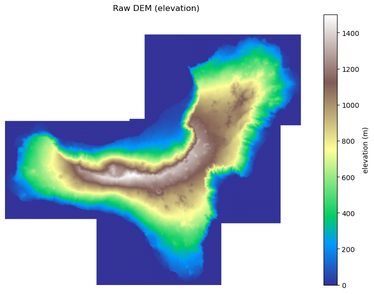

In [6]:
# panel 1 -> fig_channels_1.png
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(dem_h, cmap="terrain"); ax.set_title("Raw DEM (elevation)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("elevation (m)")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_channels_1.png", dpi=120, bbox_inches="tight"); plt.show()

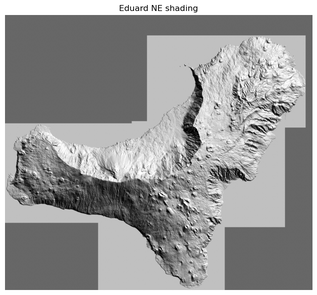

In [7]:
# panel 2 -> fig_channels_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(ne,  cmap="gray"); ax.set_title("Eduard NE shading")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_channels_2.png", dpi=120, bbox_inches="tight"); plt.show()

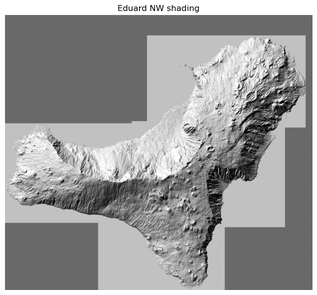

In [8]:
# panel 3 -> fig_channels_3.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(nw,  cmap="gray"); ax.set_title("Eduard NW shading")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_channels_3.png", dpi=120, bbox_inches="tight"); plt.show()

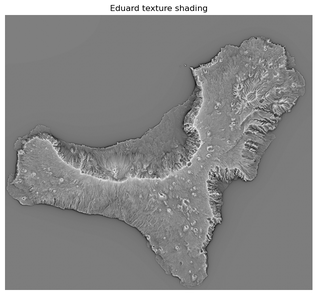

In [9]:
# panel 4 -> fig_channels_4.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(tex, cmap="gray"); ax.set_title("Eduard texture shading")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_channels_4.png", dpi=120, bbox_inches="tight"); plt.show()

In [10]:
# Figure 2 - ground-truth crater outlines + zoom on the closest pair (reuses craters, cen)
from scipy.spatial import cKDTree
d, idx = cKDTree(cen).query(cen, k=2)
i = int(np.argmin(d[:, 1]))
cx, cy = cen[i]
r0, c0 = rowcol(transform_h, cx, cy)
half = 120  # pixels (~600 m at 5 m/px)

def outline_px(geom):
    xs, ys = geom.xy
    rr, cc = rowcol(transform_h, list(xs), list(ys))
    return np.asarray(cc), np.asarray(rr)
print(f"Craters: {len(craters)} | closest pair distance: {d[i,1]:.0f} m")

Craters: 196 | closest pair distance: 25 m


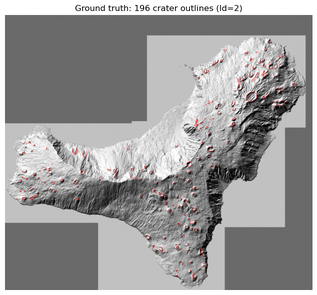

In [11]:
# panel 1 -> fig_gt_1.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(nw, cmap="gray")
for g in craters.geometry:
    cc, rr = outline_px(g); ax.plot(cc, rr, color="red", lw=0.4)
ax.set_title(f"Ground truth: {len(craters)} crater outlines (Id=2)"); ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_gt_1.png", dpi=120, bbox_inches="tight"); plt.show()

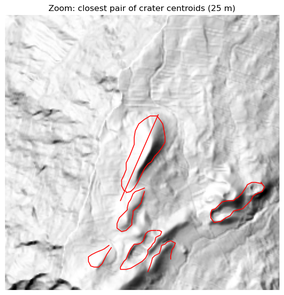

In [12]:
# panel 2 -> fig_gt_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(nw, cmap="gray")
for g in craters.geometry:
    cc, rr = outline_px(g); ax.plot(cc, rr, color="red", lw=1.2)
ax.set_xlim(c0 - half, c0 + half); ax.set_ylim(r0 + half, r0 - half)
ax.set_title("Zoom: closest pair of crater centroids (25 m)"); ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_gt_2.png", dpi=120, bbox_inches="tight"); plt.show()

**The adjacent / nested cases, up close.** <br>
The gallery below isolates every crater whose
nearest neighbour is closer than the sum of the two radii (their outlines overlap). 

These
are the cases a point-based blob detector collapses into a single detection, and exactly
what the watershed step must split apart.

In [13]:
# Gallery: all adjacent / nested crater pairs (outlines overlap) -- reuses craters, cen, rad
from scipy.spatial import cKDTree
dist, idx = cKDTree(cen).query(cen, k=2)
adj = dist[:, 1] < (rad + rad[idx[:, 1]])

pairs = sorted({frozenset((i, int(idx[i, 1]))) for i in np.where(adj)[0]}, key=min)
pairs = [tuple(p) for p in pairs]

ncols = 1; nrows = len(pairs)

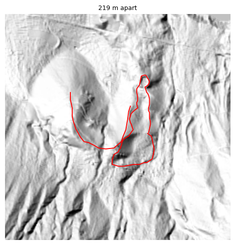

In [14]:
# panel 1 -> fig_adjacent_1.png
fig, ax = plt.subplots(figsize=(7, 5))
i, j = pairs[0]
mx, my = (cen[i] + cen[j]) / 2
rr, cc = rowcol(transform_h, mx, my)
half = int(max(60, 2.2 * (rad[i] + rad[j]) / 5.0))   # 5 m/px
ax.imshow(nw, cmap="gray")
for g in craters.geometry:
    gc, gr2 = outline_px(g); ax.plot(gc, gr2, color="red", lw=1.3)
ax.set_xlim(cc - half, cc + half); ax.set_ylim(rr + half, rr - half)
dij = np.linalg.norm(cen[i] - cen[j])
ax.set_title(f"{dij:.0f} m apart", fontsize=9); ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_adjacent_1.png", dpi=120, bbox_inches="tight"); plt.show()

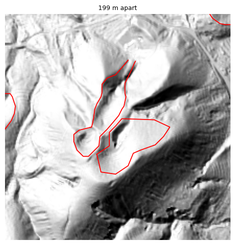

In [15]:
# panel 2 -> fig_adjacent_2.png
fig, ax = plt.subplots(figsize=(7, 5))
i, j = pairs[1]
mx, my = (cen[i] + cen[j]) / 2
rr, cc = rowcol(transform_h, mx, my)
half = int(max(60, 2.2 * (rad[i] + rad[j]) / 5.0))   # 5 m/px
ax.imshow(nw, cmap="gray")
for g in craters.geometry:
    gc, gr2 = outline_px(g); ax.plot(gc, gr2, color="red", lw=1.3)
ax.set_xlim(cc - half, cc + half); ax.set_ylim(rr + half, rr - half)
dij = np.linalg.norm(cen[i] - cen[j])
ax.set_title(f"{dij:.0f} m apart", fontsize=9); ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_adjacent_2.png", dpi=120, bbox_inches="tight"); plt.show()

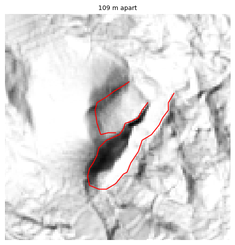

In [16]:
# panel 3 -> fig_adjacent_3.png
fig, ax = plt.subplots(figsize=(7, 5))
i, j = pairs[2]
mx, my = (cen[i] + cen[j]) / 2
rr, cc = rowcol(transform_h, mx, my)
half = int(max(60, 2.2 * (rad[i] + rad[j]) / 5.0))   # 5 m/px
ax.imshow(nw, cmap="gray")
for g in craters.geometry:
    gc, gr2 = outline_px(g); ax.plot(gc, gr2, color="red", lw=1.3)
ax.set_xlim(cc - half, cc + half); ax.set_ylim(rr + half, rr - half)
dij = np.linalg.norm(cen[i] - cen[j])
ax.set_title(f"{dij:.0f} m apart", fontsize=9); ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_adjacent_3.png", dpi=120, bbox_inches="tight"); plt.show()

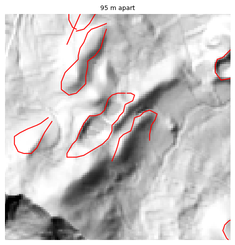

In [17]:
# panel 4 -> fig_adjacent_4.png
fig, ax = plt.subplots(figsize=(7, 5))
i, j = pairs[3]
mx, my = (cen[i] + cen[j]) / 2
rr, cc = rowcol(transform_h, mx, my)
half = int(max(60, 2.2 * (rad[i] + rad[j]) / 5.0))   # 5 m/px
ax.imshow(nw, cmap="gray")
for g in craters.geometry:
    gc, gr2 = outline_px(g); ax.plot(gc, gr2, color="red", lw=1.3)
ax.set_xlim(cc - half, cc + half); ax.set_ylim(rr + half, rr - half)
dij = np.linalg.norm(cen[i] - cen[j])
ax.set_title(f"{dij:.0f} m apart", fontsize=9); ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_adjacent_4.png", dpi=120, bbox_inches="tight"); plt.show()

**Ground-truth quality.** 

The crater outlines (Id=2) are *dirty*, which is why we will
rely on crater **centroids** (plus an approximate radius) rather than the exact outline shape:
<br>
- **191 of 196 are open** polylines (only 5 are closed, i.e. first point = last point);<br>
- the **start–end gap** has median **41 m**, up to **555 m**;<br>
- the **vertex count** has median 19, but **some outlines have only 2 points** (a plain segment).

**Label semantics (data-driven).** El Hierro stores three feature types in one shapefile,
identified by `Id` and confirmed by the geometry tests above:
<br>
- *Id=1 — base*: large, roundish outline (median length 846 m, aspect 1.3) that **encloses the
  crater in 98% of cones**;<br>
- *Id=2 — crater rim*: smaller roundish outline (457 m, aspect 1.5) — **our detection target**;<br>
- *Id=3 — fissure*: a short, strongly **elongated** segment (median 2 vertices, aspect 8.3) that
  always carries a non-zero azimuth;<br>
- *`Prj_Az`*: the **fissure azimuth** in degrees (0–359), non-zero only for Id=3;<br>
- *`pericolosi`*: a hazard level (values 0/1/2).

In [18]:
# Ground-truth quality and label semantics (tests)
from shapely.geometry import Polygon

gtf = gt  # reuse the full ground truth parsed once in the setup cell

def n_verts(g):  return len(g.xy[0])
def is_closed(g):
    x, y = g.xy; return x[0] == x[-1] and y[0] == y[-1]
def gap(g):
    x, y = g.xy; return ((x[0]-x[-1])**2 + (y[0]-y[-1])**2) ** 0.5
def aspect(g):
    try:
        x, y = g.minimum_rotated_rectangle.exterior.xy
        p = np.array(list(zip(x, y)))[:-1]
        s = [np.linalg.norm(p[i]-p[(i+1) % 4]) for i in range(4)]
        return max(s) / (min(s) + 1e-9)
    except Exception:
        return np.nan
def area(g):
    try: return Polygon(g.coords).area
    except Exception: return np.nan

# (a) crater outline quality (Id=2)
cra = gtf[gtf["Id"] == 2]
nopen = sum(not is_closed(g) for g in cra.geometry)
gaps  = np.array([gap(g) for g in cra.geometry])
verts = np.array([n_verts(g) for g in cra.geometry])
print("Crater outlines (Id=2):", len(cra), "| open", nopen, "| closed", len(cra)-nopen)
print(f"  start-end gap (m): median {np.median(gaps):.0f} | max {gaps.max():.0f}")
print(f"  vertices: median {int(np.median(verts))} | min {verts.min()}")
print()
# (b) label semantics per Id
print("Id  feature   n     verts  len(m)  aspect  Prj_Az!=0")
names = {1: "base", 2: "crater", 3: "fissure"}
for i in [1, 2, 3]:
    s = gtf[gtf["Id"] == i]
    v  = int(np.median([n_verts(g) for g in s.geometry]))
    L  = np.median(s.geometry.length.values)
    a  = np.nanmedian([aspect(g) for g in s.geometry])
    nz = 100 * np.count_nonzero(s["Prj_Az"].values) / len(s)
    print(f"{i}   {names[i]:8} {len(s):4}  {v:5}  {L:6.0f}  {a:6.2f}  {nz:5.0f}%")
print()
# (c) nesting: base larger than crater
big = tot = 0
for _, grp in gtf.groupby("coni"):
    a1 = grp[grp.Id == 1].geometry.apply(area)
    a2 = grp[grp.Id == 2].geometry.apply(area)
    if len(a1) and len(a2):
        tot += 1; big += a1.mean() > a2.mean()
print(f"Base larger than crater: {big}/{tot} cones ({100*big/tot:.0f}%)")

Crater outlines (Id=2): 196 | open 191 | closed 5
  start-end gap (m): median 40 | max 556
  vertices: median 19 | min 2

Id  feature   n     verts  len(m)  aspect  Prj_Az!=0
1   base      151     29     846    1.29      0%
2   crater    196     19     457    1.47      0%
3   fissure   171      2     272    8.32    100%



Base larger than crater: 145/148 cones (98%)


**How to read the output above.** The three printed blocks answer three questions about the labels.
<br>

- **(a) Crater outline quality** — of the 196 crater outlines (`Id=2`), **191 are *open*** (first vertex ≠ last vertex) and only 5 close up. 

The *start–end gap* is the straight-line distance between the first and last vertex of an outline (median **40 m**, up to **556 m** → some outlines are very far from closing), and the *vertex count* drops to as low as **2** (a plain segment). 

Take-away: the outlines are too unreliable to use as exact shapes, so we work with crater **centroids + an approximate radius** instead.<br>

- **(b) Per-label table** — one row per `Id`, median values across all features of that type. Columns:<br>
   • *n*: how many features carry that `Id`;<br>
   • *verts*: median number of vertices per outline (shape detail);<br>
   • *len(m)*: median outline length in metres (size);<br>
   • *aspect*: elongation of the minimum bounding rectangle, longer side / shorter side (**≈1 = round**, **≫1 = stretched**);<br>
   • *Prj_Az≠0*: share of features whose azimuth field is non-zero.<br>

  Reading across the rows the labels separate cleanly: **Id=1** is long and round (846 m, aspect 1.3) → the cone **base**; **Id=2** is medium and round (457 m, aspect 1.5) → the **crater rim**, our target; **Id=3** has just 2 vertices, aspect **8.3** and **100% non-zero azimuth** → a **fissure** (an elongated line with a direction).<br>

- **(c) Nesting check** — for **145 of 148 cones (98%)** the base outline (`Id=1`) has a larger area than its crater (`Id=2`), confirming the geometry we expect: the small crater sits **inside** the wider cone base.


**Observation (what these data fix for the pipeline).** The geometry tests settle the three labels and turn them into three concrete decisions:
<br>

- the **crater** (`Id=2`) is the **detection target** — it is the only label present on *every* cone (196), and since its outlines are open/dirty we represent each crater by its **centroid + equivalent radius**, not by the polygon;<br>
- the **base** (`Id=1`) encloses the crater in **98%** of cones: this containment *is* the nested configuration our contribution must preserve, and it offers a free sanity check on a detection (a real crater sits inside a wider, rounder base);<br>
- the **fissure** (`Id=3`), a short segment carrying a real azimuth (`Prj_Az`), is **not** a target but feeds the qualitative cone–fissure alignment of the bonus step.

Note also that the labels are **not equinumerous** (151 base / 196 crater / 171 fissure): annotations are incomplete, so we anchor the whole pipeline on the complete crater set rather than on bases or fissures.

---

## Step 0.6 — Quick data analysis

Three cheap checks on El Hierro that *parameterise* the later steps instead of guessing:
<br>
**1. Cone size distribution** &rarr; the equivalent radius of each crater fixes the
**scale range of the LoG detector** (Step&nbsp;4) and the watershed marker scale.<br>
**2. Nearest-neighbour distances** &rarr; how many cones sit closer than the sum of their
radii, i.e. **adjacent / nested** — this quantifies the problem the watershed step solves.<br>
**3. Rendering &harr; DEM alignment** &rarr; safety check that the Eduard renderings share
the DEM grid (same shape and transform), so overlays are pixel-exact.

In [19]:
# 3. Rendering <-> DEM alignment
with rasterio.open(HIERRO_DEM) as s:
    dem_shape, dem_tr = (s.height, s.width), s.transform
print(f"DEM            shape={dem_shape}")
for fn in ["Hierro-Eduard-Analytical-NE.tiff",
           "Hierro-Eduard-Analytical-NW.tiff",
           "Hierro-Eduard-Texture.tiff"]:
    with rasterio.open(HIERRO_REND / fn) as s:
        ok = (s.height, s.width) == dem_shape and s.transform == dem_tr
        print(f"{fn:38} shape={(s.height,s.width)}  {'aligned' if ok else 'MISALIGNED'}")

DEM            shape=(5081, 5681)
Hierro-Eduard-Analytical-NE.tiff       shape=(5081, 5681)  aligned
Hierro-Eduard-Analytical-NW.tiff       shape=(5081, 5681)  aligned
Hierro-Eduard-Texture.tiff             shape=(5081, 5681)  aligned


In [20]:
# 1+2. Cone sizes and nearest-neighbour distances (El Hierro craters) -- reuses craters, cen, rad
from scipy.spatial import cKDTree
d, idx = cKDTree(cen).query(cen, k=2)
nn_dist, nn_idx = d[:, 1], idx[:, 1]
adj = nn_dist < (rad + rad[nn_idx])           # outlines overlap -> adjacent / nested
n_adj = int(np.nansum(adj))

r = rad[np.isfinite(rad)]
print(f"Craters: {len(craters)}")
print(f"Radius (m)  -> min {r.min():.0f} | 5th {np.percentile(r,5):.0f} | "
      f"median {np.median(r):.0f} | 95th {np.percentile(r,95):.0f} | max {r.max():.0f}")
print(f"Suggested LoG radius range: {np.percentile(r,5):.0f}-{np.percentile(r,95):.0f} m")
print(f"NN distance (m) -> min {nn_dist.min():.0f} | median {np.median(nn_dist):.0f}")
print(f"Adjacent/nested craters (NN < r_i+r_j): {n_adj} / {len(craters)} "
      f"({100*n_adj/len(craters):.0f}%)")

Craters: 196
Radius (m)  -> min 6 | 5th 20 | median 71 | 95th 174 | max 457
Suggested LoG radius range: 20-174 m
NN distance (m) -> min 25 | median 418
Adjacent/nested craters (NN < r_i+r_j): 8 / 196 (4%)


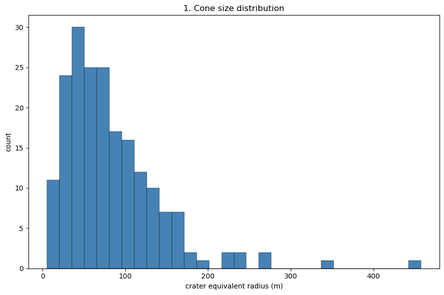

In [21]:
# panel 1 -> fig_data_stats_1.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(r, bins=30, color="steelblue", edgecolor="k", lw=0.3)
ax.set_xlabel("crater equivalent radius (m)"); ax.set_ylabel("count")
ax.set_title("1. Cone size distribution")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_data_stats_1.png", dpi=120, bbox_inches="tight"); plt.show()

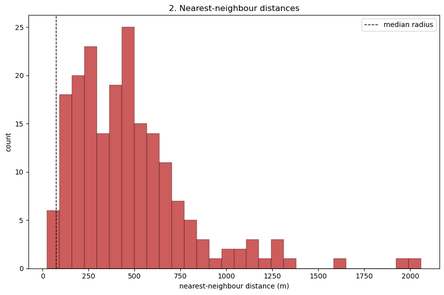

In [22]:
# panel 2 -> fig_data_stats_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(nn_dist, bins=30, color="indianred", edgecolor="k", lw=0.3)
ax.axvline(np.median(r), color="k", ls="--", lw=1, label="median radius")
ax.set_xlabel("nearest-neighbour distance (m)"); ax.set_ylabel("count")
ax.set_title("2. Nearest-neighbour distances"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_data_stats_2.png", dpi=120, bbox_inches="tight"); plt.show()

**Reading the numbers.**<br>
*196 craters*: the number of crater annotations in the El Hierro ground truth.<br>
*Radius*: cones span a wide size range — the smallest crater is ~6 m, half are below **71 m**, and 90% fall between **20 and 174 m** (largest 457 m).<br>
*LoG range 20–174 m*: we will look for blobs only at these scales (the 5th–95th percentile), ignoring the rare tiny/huge outliers.<br>
*NN distance*: cones are typically **~418 m** apart, but the two closest sit only **25 m** apart.<br>
*Adjacent/nested 8/196 (4%)*: 8 craters have a neighbour so close that their outlines overlap — these are the merging cases the watershed step must separate.

**Observation (what these three checks fix for the pipeline).** Put together, the measurements set three things at once:
<br>

- **Alignment** — the Eduard renderings share the DEM grid exactly (same shape and transform), so every DEM-derived channel and the supplied shadings can be **stacked as co-registered inputs**, with no resampling;<br>
- **Scale** — the crater sizes fix the **LoG search range to 20–174 m** (5th–95th percentile, median 71 m): the detector looks only at these radii and ignores the rare tiny/huge outliers;<br>
- **Difficulty** — only **8/196 cones (4%)** have overlapping outlines, but this 4% is exactly the population a point-based detector **merges into a single response**; it is the quantitative target the watershed step is built to recover.

In short, these numbers *parameterise* the detector (scale range), *guarantee* clean multi-channel inputs (alignment), and *size* the problem the contribution must solve (the 4% adjacent/nested cones).

---

## Step 1 — Morphometric channels: slope, aspect, roughness

From the single elevation band we derive three channels that make the cones visible, using
the **image gradient** (deck `01_image_processing`, p.13):
<br>
- **slope** $=\arctan\sqrt{g_x^2+g_y^2}$ (degrees) — steepness of the terrain;<br>
- **aspect** $=\operatorname{atan2}(g_y,g_x)$ — the direction the slope faces;<br>
- **roughness** $=$ local standard deviation in a $k\times k$ window — surface texture.

These three channels (plus the texture rendering) are the input of every later step.
*Test:* slope is markedly higher on the crater rims than on the background, and the aspect
rotates through $360^\circ$ around a cone (radial pattern).

In [23]:
from scipy.ndimage import sobel, uniform_filter

def compute_slope(dem, res):
    """Slope in degrees from the Sobel gradient magnitude."""
    f = np.nan_to_num(dem)
    gx = sobel(f, axis=1) / (8 * res[0])
    gy = sobel(f, axis=0) / (8 * res[1])
    slope = np.degrees(np.arctan(np.hypot(gx, gy)))
    slope[np.isnan(dem)] = np.nan
    return slope

def compute_aspect(dem, res):
    """Aspect (gradient orientation) in degrees, 0-360."""
    f = np.nan_to_num(dem)
    gx = sobel(f, axis=1) / (8 * res[0])
    gy = sobel(f, axis=0) / (8 * res[1])
    aspect = np.degrees(np.arctan2(gy, gx)) % 360
    aspect[np.isnan(dem)] = np.nan
    return aspect

def compute_roughness(dem, window=5):
    """Local standard deviation of elevation in a window x window box."""
    f = np.nan_to_num(dem)
    mean   = uniform_filter(f, window)
    meansq = uniform_filter(f * f, window)
    rough  = np.sqrt(np.clip(meansq - mean * mean, 0, None))
    rough[np.isnan(dem)] = np.nan
    return rough

slope_h = compute_slope(dem_h, res_h)
aspect_h = compute_aspect(dem_h, res_h)
rough_h  = compute_roughness(dem_h, window=5)

# Test: slope on crater rims vs background (reuses craters)
rs = []
for g in craters.geometry:
    xs, ys = g.xy
    rr, cc = rowcol(transform_h, list(xs), list(ys))
    rr = np.clip(rr, 0, slope_h.shape[0]-1); cc = np.clip(cc, 0, slope_h.shape[1]-1)
    rs.extend(slope_h[rr, cc])
rs = np.array(rs, float)
print(f"slope on crater rims : median {np.nanmedian(rs):.1f} deg")
print(f"slope background     : median {np.nanmedian(slope_h):.1f} deg")
print(f"roughness            : median {np.nanmedian(rough_h):.2f} m")

slope on crater rims : median 18.8 deg
slope background     : median 8.1 deg


roughness            : median 1.11 m


**What these numbers mean.** 

The crater rims are about **2.3× steeper** than the surrounding terrain ($18.8^\circ$ vs $8.1^\circ$): slope alone already separates the cone flanks from the flat background, which is why it will drive the morphometric mask of Step 3. 

The background roughness is low (median $1.11$ m), so roughness mostly flags the few rough/built-up spots and serves as a **secondary cue**, not the main one.

In [24]:
# Visualise the three channels + a zoom showing the radial aspect on one cone (2x2 grid)
big = int(np.nanargmax(rad))  # largest crater (reuses cen, rad)
br, bc = rowcol(transform_h, cen[big, 0], cen[big, 1]); half = 80

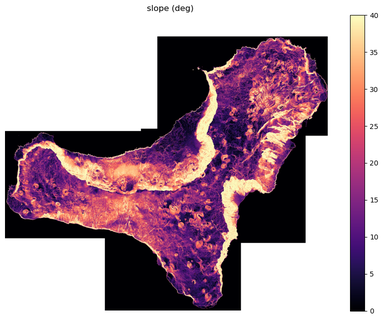

In [25]:
# panel 1 -> fig_morphometric_1.png
fig, ax = plt.subplots(figsize=(8, 6.5))
im0 = ax.imshow(slope_h, cmap="magma", vmax=40); ax.set_title("slope (deg)")
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_morphometric_1.png", dpi=120, bbox_inches="tight"); plt.show()

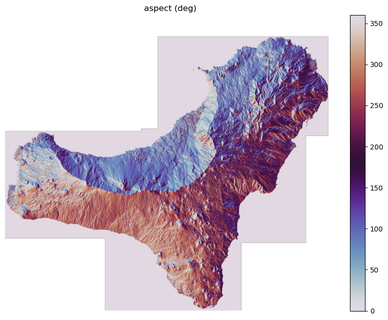

In [26]:
# panel 2 -> fig_morphometric_2.png
fig, ax = plt.subplots(figsize=(8, 6.5))
im1 = ax.imshow(aspect_h, cmap="twilight"); ax.set_title("aspect (deg)")
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_morphometric_2.png", dpi=120, bbox_inches="tight"); plt.show()

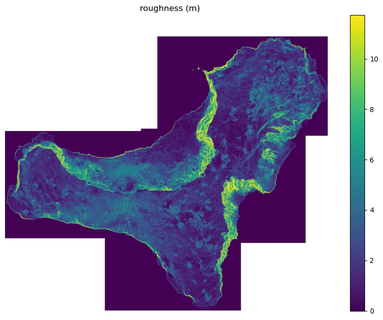

In [27]:
# panel 3 -> fig_morphometric_3.png
fig, ax = plt.subplots(figsize=(8, 6.5))
im2 = ax.imshow(rough_h, cmap="viridis", vmax=np.nanpercentile(rough_h, 99)); ax.set_title("roughness (m)")
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_morphometric_3.png", dpi=120, bbox_inches="tight"); plt.show()

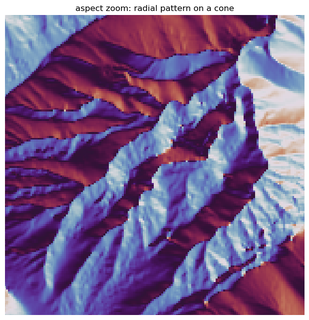

In [28]:
# panel 4 -> fig_morphometric_4.png
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.imshow(aspect_h, cmap="twilight")
ax.set_xlim(bc-half, bc+half); ax.set_ylim(br+half, br-half)
ax.set_title("aspect zoom: radial pattern on a cone")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_morphometric_4.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.** 

Cones show up as **bright rings** in slope/roughness and as **radial colour wheels** in aspect (one full hue rotation per cone, clear in the zoom). The one catch: the **coastal cliff** is just as steep as a crater rim — a steep-but-not-a-cone case — so Step 3 will combine slope *with* roughness rather than thresholding slope alone.

---

## Step 2 — Synthetic hillshade from steerable filters

Instead of relying on the supplied Eduard NE/NW renders, we **synthesise** the hillshade from
any light azimuth ourselves, using **steerable first-derivative-of-Gaussian filters** (deck
`01_image_processing`, p.22). 

We filter the DEM once along $x$ and $y$ to get the two basis
responses $G_1^{0°}$ and $G_1^{90°}$; the derivative along any direction $\theta$ is then a
cheap linear combination — no re-filtering:
<br>

$$G_1^{\theta} = \cos\theta\,G_1^{0°} + \sin\theta\,G_1^{90°}$$

The shading lit from compass azimuth $\theta$ is the directional derivative along the light
(bright where the surface rises toward the light). 

With $\sigma=2$ px ($\approx 10$ m) the
synthetic NE hillshade matches the supplied Eduard NE render.
<br>

*Test:* (1) the synthetic NE shading correlates with the Eduard NE render; (2) changing
$\theta$ rotates the illumination coherently.

**Role in the pipeline.** The synthetic hillshade is *not* a classifier feature; its purpose is methodological and diagnostic: (1) it demonstrates the course's steerable-filter construction on the real DEM; (2) the 0.81 correlation with the Eduard render validates the same gradient machinery that drives slope, aspect and the radial-coherence feature; (3) it makes relief shading self-produced, so the pipeline does not depend on supplied renders (relevant on datasets without them, e.g. Jeju). It is then reused only as the grayscale background of every later figure.

In [29]:
# Step 2 - synthetic hillshade via steerable first-derivative-of-Gaussian filters
from scipy.ndimage import gaussian_filter

def dog_basis(dem, sigma=2):
    """The two steerable basis responses: G1^0 (d/dx) and G1^90 (d/dy)."""
    f = np.nan_to_num(dem)
    g0  = gaussian_filter(f, sigma, order=(0, 1))   # derivative along columns (east)
    g90 = gaussian_filter(f, sigma, order=(1, 0))   # derivative along rows (south)
    return g0, g90

def steer_hillshade(g0, g90, az_deg):
    """Relief shading lit from compass azimuth az_deg via G1^theta = cos.G1^0 + sin.G1^90."""
    A = np.radians(az_deg)
    d = np.sin(A) * g0 - np.cos(A) * g90            # steerable directional derivative
    # NOTE: tested - with +d the synthetic shading is INVERTED w.r.t. the Eduard render
    # (corr -0.81); negating the directional derivative flips it to bright-where-lit (corr +0.81).
    s = np.where(valid, -d, np.nan)                 # -d: bright where the surface faces the light
    lo, hi = np.nanpercentile(s, [2, 98])
    return np.clip((s - lo) / (hi - lo + 1e-9), 0, 1)

g0, g90 = dog_basis(dem_h, sigma=2)                 # filtered once; reused for every azimuth

hs_ne = steer_hillshade(g0, g90, 45)
hs_nw = steer_hillshade(g0, g90, 315)
hs_se = steer_hillshade(g0, g90, 135)

# Test 1: synthetic NE vs the supplied Eduard NE render
eduard_ne = load_norm(HIERRO_REND / "Hierro-Eduard-Analytical-NE.tiff")
m = valid & np.isfinite(eduard_ne) & np.isfinite(hs_ne)
corr = np.corrcoef(hs_ne[m], eduard_ne[m])[0, 1]
print(f"sigma = 2 px (~10 m); two base filters reused for all azimuths")
print(f"corr(synthetic NE hillshade, Eduard NE render) = {corr:.2f}")

sigma = 2 px (~10 m); two base filters reused for all azimuths
corr(synthetic NE hillshade, Eduard NE render) = 0.81


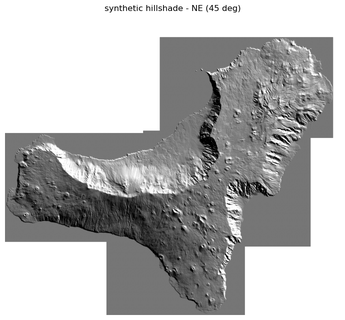

In [30]:
# panel 1 -> fig_steerable_1.png
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.imshow(hs_ne, cmap="gray"); ax.set_title("synthetic hillshade - NE (45 deg)")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_steerable_1.png", dpi=120, bbox_inches="tight"); plt.show()

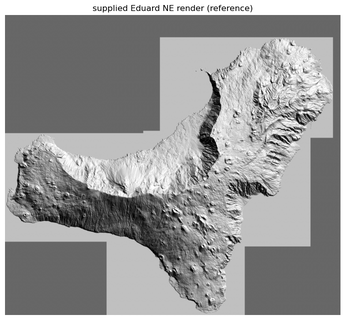

In [31]:
# panel 2 -> fig_steerable_2.png
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.imshow(eduard_ne, cmap="gray"); ax.set_title("supplied Eduard NE render (reference)")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_steerable_2.png", dpi=120, bbox_inches="tight"); plt.show()

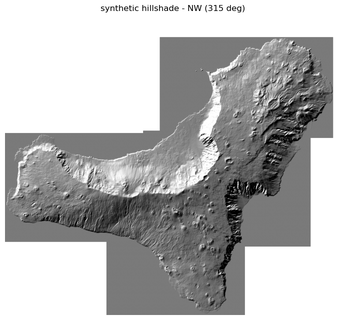

In [32]:
# panel 3 -> fig_steerable_3.png
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.imshow(hs_nw, cmap="gray"); ax.set_title("synthetic hillshade - NW (315 deg)")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_steerable_3.png", dpi=120, bbox_inches="tight"); plt.show()

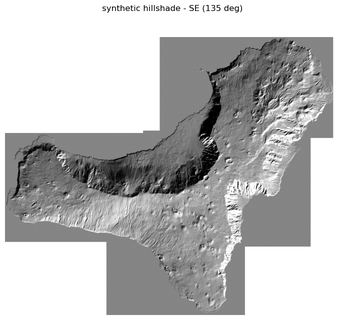

In [33]:
# panel 4 -> fig_steerable_4.png
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.imshow(hs_se, cmap="gray"); ax.set_title("synthetic hillshade - SE (135 deg)")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_steerable_4.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.** The synthetic NE hillshade reproduces the Eduard NE render (corr $\approx 0.81$) from just **two** Gaussian-derivative filters, and rotating $\theta$ swings the illumination and shadows coherently (NE vs NW vs SE). 

This gives us a **CV-grounded, self-produced** multi-direction shading we control — unlike the fixed NE/NW renders — useful to make the cone flanks pop from any light angle in the next steps.

> **Technical note (tested).** With the raw directional derivative the synthetic shading comes out *inverted* relative to the Eduard render (corr $-0.81$): our light-direction convention is opposite to theirs. Negating it (`s = -d`, bright where the surface faces the light) flips the sign to corr $+0.81$, matching Eduard.

---

## Step 3 — Data-driven morphometric mask

We reduce the search area for the blob detector (Step 4) to the **steep terrain** where cones
live, with a binary mask obtained by **thresholding the slope** (deck `09_segmentation`,
p.13–18). 

The threshold is **not hand-picked**: we let **Otsu's method** choose the global
optimum that best splits the slope histogram into *flat* and *steep* (between-class variance).
<br>

Notably Otsu lands at $\approx 17.6^\circ$, right on the rim slope we *measured* in Step 1
($18.8^\circ$) — confirming the cut is meaningful. The original plan used a fixed band
$[25^\circ,35^\circ]$, but with the real data that misses most rims (rim-recall $21\%$), which
is exactly why we switched to a data-driven threshold. 

A roughness AND-term was also tested but
gave no gain (cone rims are already both steep and rough), so we keep the single-channel mask.
<br>

*Test:* the mask must keep only a fraction of the island yet still cover the cones.

In [34]:
# Step 3 - data-driven morphometric mask: Otsu threshold on slope
# reuses slope_h, valid (setup/Step 1) and cen, rad (setup); produces `mask` for Step 4
from skimage.filters import threshold_otsu

T_slope = threshold_otsu(slope_h[valid])         # optimal flat/steep split (between-class variance)
mask = (slope_h > T_slope) & valid

# per-cone recall: does steep terrain cover each cone's disk? (more meaningful than per-vertex)
radpx = np.where(np.isfinite(rad), rad, np.nanmedian(rad)) / res_h[0]
H, W = slope_h.shape; hit = 0
for (x, y), rp in zip(cen, radpx):
    rr, cc = rowcol(transform_h, x, y); rpx = max(2, int(rp))
    sub = mask[max(0, rr-rpx):rr+rpx+1, max(0, cc-rpx):cc+rpx+1]
    if sub.size and sub.mean() > 0.10: hit += 1        # >=10% of the cone disk is steep
coverage = 100 * mask[valid].sum() / valid.sum()
recall   = 100 * hit / len(cen)
print(f"Otsu threshold on slope = {T_slope:.1f} deg   (measured rim slope ~18.8 deg)")
print(f"island coverage kept    = {coverage:.0f}%")
print(f"per-cone recall         = {recall:.0f}% of {len(cen)} cones (>=10% of the cone disk is steep)")
print(f"note: a roughness AND-term was tested -> no gain (rims are both steep and rough)")

# figure: histogram+Otsu, binary mask, overlay (on the Step 2 hillshade), zoom
big = int(np.nanargmax(rad)); br, bc = rowcol(transform_h, cen[big, 0], cen[big, 1]); half = 80

Otsu threshold on slope = 17.6 deg   (measured rim slope ~18.8 deg)
island coverage kept    = 31%
per-cone recall         = 96% of 196 cones (>=10% of the cone disk is steep)
note: a roughness AND-term was tested -> no gain (rims are both steep and rough)


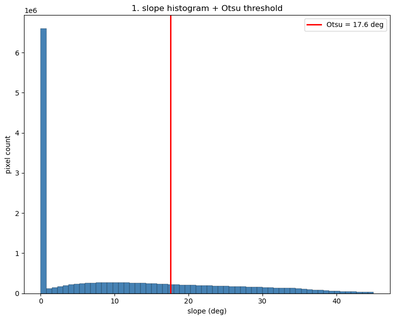

In [35]:
# panel 1 -> fig_mask_1.png
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.hist(slope_h[valid], bins=60, range=(0, 45), color="steelblue", edgecolor="k", lw=0.2)
ax.axvline(T_slope, color="red", lw=2, label=f"Otsu = {T_slope:.1f} deg")
ax.set_xlabel("slope (deg)"); ax.set_ylabel("pixel count")
ax.set_title("1. slope histogram + Otsu threshold"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_mask_1.png", dpi=120, bbox_inches="tight"); plt.show()

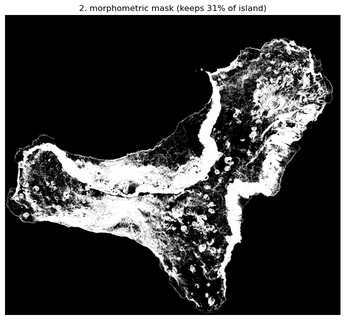

In [36]:
# panel 2 -> fig_mask_2.png
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.imshow(mask, cmap="gray"); ax.axis("off")
ax.set_title(f"2. morphometric mask (keeps {coverage:.0f}% of island)")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_mask_2.png", dpi=120, bbox_inches="tight"); plt.show()

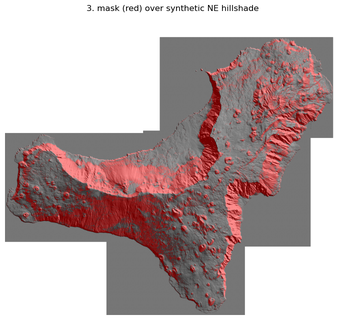

In [37]:
# panel 3 -> fig_mask_3.png
fig, ax = plt.subplots(figsize=(8, 6.5))
red = np.ma.masked_where(~mask, np.ones_like(mask, float))
ax.imshow(hs_ne, cmap="gray"); ax.imshow(red, cmap="autumn", alpha=0.45)
ax.set_title("3. mask (red) over synthetic NE hillshade"); ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_mask_3.png", dpi=120, bbox_inches="tight"); plt.show()

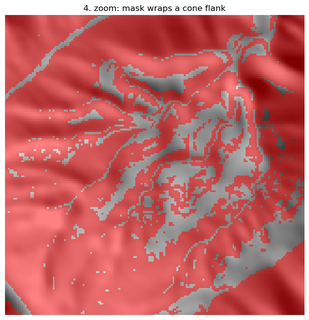

In [38]:
# panel 4 -> fig_mask_4.png
fig, ax = plt.subplots(figsize=(8, 6.5))
red = np.ma.masked_where(~mask, np.ones_like(mask, float))
ax.imshow(hs_ne, cmap="gray"); ax.imshow(red, cmap="autumn", alpha=0.5)
ax.set_xlim(bc-half, bc+half); ax.set_ylim(br+half, br-half)
ax.set_title("4. zoom: mask wraps a cone flank"); ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_mask_4.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.** 

Otsu splits the slope histogram at $17.6^\circ$ (panel 1), producing a mask that keeps only **31%** of the island (panel 2) yet still covers **96%** of the cones (panel 3), and the zoom shows it wrapping the steep flank of a cone like a ring (panel 4). 

So the mask is a cheap, high-recall pre-filter that throws away the flat interior before the costly blob search. 

Its one blind spot is the **coastal cliff** — steep, so it survives the mask — which will be rejected later by the classifier (Step 7), not here.

---

## Step 4 — LoG candidate detection (baseline that exposes the problem)

On the masked texture rendering we run the **Laplacian-of-Gaussian** blob detector
(`skimage.feature.blob_log`), the classic **scale-invariant** circular-feature detector
(deck `03_image_matching`, p.14–16). 

Scales come from the radii measured in Step 0.6
(20–174 m) and we keep the configuration **deliberately permissive** (low threshold) to
maximise recall: this is a high-recall candidate pool, not the final detector.
<br>

*Test:* recall ≈ 0.96 on the craters, and — the key point — once we ask
for **one detection per cone**, crowded neighbours compete for the same candidates and some are lost.

**A note on terminology** (used here and in the next steps).
<br>

- **Ground truth (GT):** the human-annotated true craters, our reference for what is correct.<br>
- **TP / FP / FN:** a *true positive* is a real cone correctly detected; a *false positive* (**FP**) is a detection matching no real cone; a *false negative* (**FN**) is a real cone we miss.<br>
- **Recall** $= \frac{TP}{TP+FN}$: fraction of real cones we find (how *complete* we are).<br>
- **Precision** $= \frac{TP}{TP+FP}$: fraction of detections that are real (how *clean* the output is).<br>
- **Blob:** a roughly circular bright/dark spot at a given scale — what the LoG detector returns.<br>
- **One-to-one assignment:** forcing each detection to serve at most one cone (one detection per cone), as a real detector must.<br>
- **RF (Random Forest):** the supervised classifier of Step 7 — an ensemble of decision trees that will label each candidate as cone / not-cone.<br>
- **Watershed:** the region-based segmentation of Step 5 that *floods* the surface from markers and traces boundaries between adjacent basins, separating touching cones.

In [39]:
# Step 4 - permissive LoG candidate detection (skimage.feature.blob_log) -- RUNNABLE
# ~30 s: blob_log on the 2x-downsampled texture, then candidates rescaled to full res.
# reuses tex (setup), mask (Step 3), hs_ne (Step 2), craters/cen/rad (setup), res_h, transform_h.
from skimage.feature import blob_log
from scipy.spatial import cKDTree

# 1) detect blobs on the downsampled texture, then rescale (row, col, sigma) to full resolution
DS = 2
blobs = blob_log(np.nan_to_num(tex[::DS, ::DS]),
                 min_sigma=1.5, max_sigma=12, num_sigma=6, threshold=0.08, overlap=0.3)
blobs[:, :2] *= DS; blobs[:, 2] *= DS
blob_r = blobs[:, 2] * np.sqrt(2)                                  # blob radius in pixels

# 2) keep candidates whose centre falls inside the morphometric mask (Step 3)
ri = np.clip(blobs[:, 0].astype(int), 0, mask.shape[0] - 1)
ci = np.clip(blobs[:, 1].astype(int), 0, mask.shape[1] - 1)
keep = mask[ri, ci]
cand = blobs[keep, :2]; cand_r = blob_r[keep]

# 3) ground-truth crater centroids in pixels + radii (reuses cen, rad)
gr = np.array([rowcol(transform_h, x, y) for x, y in cen], float)          # (row, col)
radpx = np.where(np.isfinite(rad), rad, np.nanmedian(rad)) / res_h[0]

# 4) evaluate: lenient any-candidate recall vs strict one-to-one assignment (200 m tolerance)
tol = 200 / res_h[0]; tree = cKDTree(cand)
dnn, inn = tree.query(gr, k=1)
tp = int((dnn < tol).sum()); fn = len(gr) - tp
fp = len(cand) - len(set(inn[dnn < tol].tolist()))
recall = tp / len(gr); precision = tp / (tp + fp + 1e-9)
used = set(); matched_set = set()
for gi in np.argsort(dnn):                                        # greedy one detection per cone
    dd, ii = tree.query(gr[gi], k=min(25, len(cand)))
    for d_, k_ in zip(np.atleast_1d(dd), np.atleast_1d(ii)):
        if d_ < tol and int(k_) not in used:
            used.add(int(k_)); matched_set.add(int(gi)); break
matched = len(matched_set)
lost_cones = sorted(set(range(len(gr))) - matched_set)           # cones the one-to-one rule loses (reused by Step 5)
gap = len(gr) - matched
print(f"candidates = {len(cand):,} | recall(any) = {recall:.3f} ({tp}/{len(gr)}) | precision = {precision:.3f}")
print(f"one-to-one assignment: {matched}/{len(gr)} unique detections -> adjacency gap = {gap} cones")

# 5) figure: candidate density (panel A) + zoom on the most crowded adjacent pair (panel B)
treec = cKDTree(cen); dc, ic = treec.query(cen, k=2)
nbr_idx = ic[:, 1]                                                # nearest GT neighbour (reused by Step 5)
with np.errstate(invalid="ignore"):
    am = dc[:, 1] < (rad + rad[ic[:, 1]])                          # outlines overlap -> adjacent
am = np.where(np.isfinite(am), am, False).astype(bool)
pairs = sorted({frozenset((i, int(ic[i, 1]))) for i in np.where(am)[0]}, key=min); pairs = [tuple(p) for p in pairs]
def _ncand(i, j):
    m = (gr[i] + gr[j]) / 2; h = 2.2 * (radpx[i] + radpx[j])
    return int(((cand[:, 0] > m[0]-h) & (cand[:, 0] < m[0]+h) & (cand[:, 1] > m[1]-h) & (cand[:, 1] < m[1]+h)).sum())
pi, pj = max(pairs, key=lambda p: _ncand(*p))
zr, zc = (gr[pi] + gr[pj]) / 2; half = int(2.2 * (radpx[pi] + radpx[pj]))

candidates = 22,065 | recall(any) = 0.964 (189/196) | precision = 0.009
one-to-one assignment: 186/196 unique detections -> adjacency gap = 10 cones


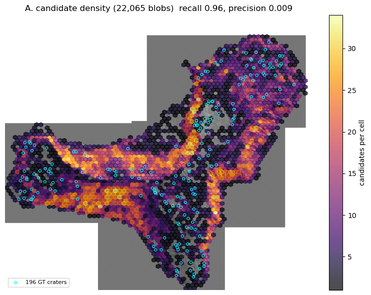

In [40]:
# panel 1 -> fig_log_1.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(hs_ne, cmap="gray")
hb = ax.hexbin(cand[:, 1], cand[:, 0], gridsize=70, cmap="inferno", mincnt=1, alpha=0.7)
ax.scatter(gr[:, 1], gr[:, 0], s=14, facecolors="none", edgecolors="cyan", linewidths=0.8, label="196 GT craters")
ax.set_title(f"A. candidate density ({len(cand):,} blobs)  recall {recall:.2f}, precision {precision:.3f}")
ax.axis("off"); ax.legend(loc="lower left", fontsize=8)
fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04).set_label("candidates per cell")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_log_1.png", dpi=120, bbox_inches="tight"); plt.show()

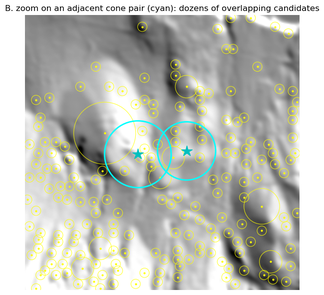

In [41]:
# panel 2 -> fig_log_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(hs_ne, cmap="gray")
inz = (cand[:, 0] > zr-half) & (cand[:, 0] < zr+half) & (cand[:, 1] > zc-half) & (cand[:, 1] < zc+half)
for k in np.where(inz)[0]:
    ax.add_patch(plt.Circle((cand[k, 1], cand[k, 0]), cand_r[k], color="yellow", fill=False, lw=0.8, alpha=0.8))
ax.scatter(cand[inz, 1], cand[inz, 0], s=4, c="yellow")
for k in (pi, pj):
    rk, ck = rowcol(transform_h, cen[k, 0], cen[k, 1])
    ax.add_patch(plt.Circle((ck, rk), radpx[k], color="cyan", fill=False, lw=2.0)); ax.plot(ck, rk, "c*", ms=16)
ax.set_xlim(zc-half, zc+half); ax.set_ylim(zr+half, zr-half)
ax.set_title("B. zoom on an adjacent cone pair (cyan): dozens of overlapping candidates")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_log_2.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.** 

Panel A: the permissive LoG floods the steep terrain with **22,065** candidates —
recall is high (**0.964**, i.e. 189/196) but precision is tiny (**0.009**),
so the pool is mostly false positives, to be filtered by the Random Forest (Step 7).

Panel B: zooming on an adjacent cone pair, **dozens of overlapping candidates** pile up over the two
craters. 

Under the lenient *any-candidate* rule both count as found, but enforcing **one detection per
cone** leaves only **186/196** with a unique match: **10 cones** are lost
because crowded neighbours compete for the same blobs. 

Point-based detection cannot assign one
detection per cone here — exactly the gap the **watershed** of Step 5 is built to close.

---

## Step 5 — Watershed: separating adjacent cones (core contribution)

The LoG baseline (Step 4) finds the cones, but once we force **one detection per cone** crowded neighbours compete for the same blobs and **10 cones are lost**: a point-based detector cannot split two cones that share a candidate.

We switch to a **region-based** view. The **watershed** transform floods the inverted relief from a set of markers and traces a boundary wherever two basins meet (deck `09_segmentation`, p.8 — "separate catchment basins"; `SLIC_Superpixels`, p.4).
<br>

The DEM is first **detrended** with a Difference-of-Gaussians high-pass, so that a small cone sitting on the volcano's regional slope still becomes a local bump (otherwise only the cones near the top of the island would be local maxima of absolute elevation).
<br>

The **markers** are the significant local maxima of the detrended relief (the cone summits), kept only inside the steep-terrain neighbourhood of the Step 3 mask. The watershed then assigns **one basin per summit**, so two adjacent cones with a saddle between them fall into **two different basins**.
<br>

*Test :* on the adjacent ground-truth pairs that the LoG one-to-one rule merged, the watershed must return **two distinct basins** — recovering the cones the baseline lost.

In [42]:
# Step 5 - marker-controlled watershed that separates ADJACENT cones -- RUNNABLE
# reuses dem_h, res_h, valid (setup), mask (Step 3), hs_ne (Step 2),
#        gr, radpx, cand, pairs, lost_cones, nbr_idx (Step 4).
from scipy.ndimage import gaussian_filter, maximum_filter, label as ndlabel, binary_dilation
from skimage.morphology import disk
from skimage.segmentation import watershed, find_boundaries
from collections import Counter

DS = 2                                                            # same 2x downsampling as Step 4
dem_ds   = np.nan_to_num(dem_h, nan=np.nanmin(dem_h))[::DS, ::DS]
valid_ds = valid[::DS, ::DS]; mask_ds = mask[::DS, ::DS]
gr_ds, radpx_ds = gr / DS, radpx / DS
H, W = dem_ds.shape

# 1) detrend (Difference-of-Gaussians high-pass): cones on the regional slope become local bumps
detrend = gaussian_filter(dem_ds, 1.5) - gaussian_filter(dem_ds, 15)

# 2) markers = significant summits inside the steep-terrain neighbourhood (Step 3 mask, dilated)
summit  = (detrend == maximum_filter(detrend, size=5)) & valid_ds & (detrend > 2.5)
summit &= binary_dilation(mask_ds, disk(3))
markers, n_marks = ndlabel(summit)

# 3) flood the inverted relief from the summits -> one catchment basin per summit
basins = watershed(-detrend, markers, mask=valid_ds)

# 4) basin under each GT crater centroid
rr = np.clip(gr_ds[:, 0].astype(int), 0, H - 1)
cc = np.clip(gr_ds[:, 1].astype(int), 0, W - 1)
bas = basins[rr, cc]; cnt = Counter(bas[bas > 0])
own = sum(1 for b in bas if b > 0 and cnt[b] == 1)               # cones alone in their basin

# 5) the test: adjacent pairs put in DISTINCT basins, and cones the LoG one-to-one rule had lost
sep       = sum(1 for i, j in pairs if bas[i] > 0 and bas[j] > 0 and bas[i] != bas[j])
recovered = sum(1 for gi in lost_cones if bas[gi] > 0 and bas[gi] != bas[nbr_idx[gi]])
print(f"watershed basins         = {n_marks:,} (over-segments like the LoG pool; the RF prunes later)")
print(f"cones in their own basin = {own}/{len(gr)}")
print(f"adjacent GT pairs split  = {sep}/{len(pairs)} (the rest are tightly nested -> Step 6)")
print(f"cones lost by LoG one-to-one, now separated from their merging neighbour = {recovered}/{len(lost_cones)}")

# figure: A) basins over the island  B) zoom on an adjacent pair LoG merged but watershed splits
sep_pairs = [(i, j) for i, j in pairs if bas[i] > 0 and bas[j] > 0 and bas[i] != bas[j]]
def _crowd(i, j):
    m = (gr_ds[i] + gr_ds[j]) / 2; h = 2.2 * (radpx_ds[i] + radpx_ds[j])
    cdx, cdy = cand[:, 1] / DS, cand[:, 0] / DS
    return int(((cdy > m[0]-h) & (cdy < m[0]+h) & (cdx > m[1]-h) & (cdx < m[1]+h)).sum())
pi, pj = max(sep_pairs, key=lambda p: _crowd(*p))
zr, zc = (gr_ds[pi] + gr_ds[pj]) / 2; half = int(2.4 * (radpx_ds[pi] + radpx_ds[pj]))

rng = np.random.default_rng(0)
lut = np.vstack([[0, 0, 0], rng.random((n_marks, 3))])           # basin 0 (background) -> black
basins_rgb = lut[basins]
hs_ds = hs_ne[::DS, ::DS]

watershed basins         = 4,427 (over-segments like the LoG pool; the RF prunes later)
cones in their own basin = 184/196
adjacent GT pairs split  = 3/4 (the rest are tightly nested -> Step 6)
cones lost by LoG one-to-one, now separated from their merging neighbour = 8/10


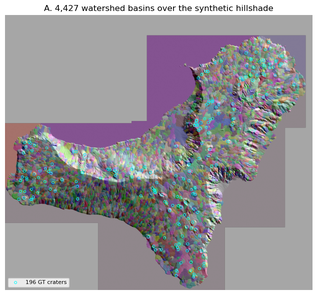

In [43]:
# panel 1 -> fig_watershed_1.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(hs_ds, cmap="gray"); ax.imshow(basins_rgb, alpha=0.35)
ax.scatter(gr_ds[:, 1], gr_ds[:, 0], s=12, facecolors="none", edgecolors="cyan",
           linewidths=0.7, label="196 GT craters")
ax.set_title(f"A. {n_marks:,} watershed basins over the synthetic hillshade")
ax.axis("off"); ax.legend(loc="lower left", fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_watershed_1.png", dpi=120, bbox_inches="tight"); plt.show()

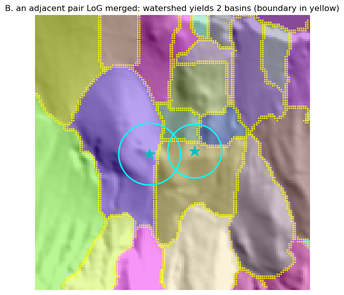

In [44]:
# panel 2 -> fig_watershed_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(hs_ds, cmap="gray"); ax.imshow(basins_rgb, alpha=0.45)
y0, y1 = max(0, int(zr-half)), int(zr+half); x0, x1 = max(0, int(zc-half)), int(zc+half)
ys, xs = np.where(find_boundaries(basins[y0:y1, x0:x1], mode="outer"))
ax.scatter(xs + x0, ys + y0, s=1.2, c="yellow")
for k in (pi, pj):
    ax.add_patch(plt.Circle((gr_ds[k, 1], gr_ds[k, 0]), radpx_ds[k], color="cyan", fill=False, lw=2))
    ax.plot(gr_ds[k, 1], gr_ds[k, 0], "c*", ms=16)
ax.set_xlim(zc-half, zc+half); ax.set_ylim(zr+half, zr-half)
ax.set_title("B. an adjacent pair LoG merged: watershed yields 2 basins (boundary in yellow)")
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_watershed_2.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.**

Panel A: the watershed partitions the island into basins, one per detected summit. Like the LoG pool it **over-segments** (thousands of basins, mostly non-cone micro-relief) — here separation is the goal and precision is left to the Random Forest (Step 7), exactly as in Step 4.

Panel B: zooming on an adjacent cone pair that the LoG baseline **merged into a single detection**, the watershed draws a boundary along the saddle and returns **two distinct basins**, one per crater.

Quantitatively, **8 of the 10** cones lost by the one-to-one LoG rule now sit in a basin separate from the neighbour they were competing with, and **3 of the 4** ground-truth adjacent pairs are split.

The one pair still merged is a **tightly nested** case (centroids only ~10 px apart, one cone on the other's flank): there is no topographic saddle between them, so it is handed to the multi-scale LoG of Step 6.

**Approaches tried and discarded** (how the method was reached ).

Restricting the watershed to the steep mask alone fails: each crater centroid sits on the flat crater floor, *outside* the steep ring, so only ~55/196 cones land in any basin — we segment the whole island instead.

Detecting markers with `peak_local_max(labels=...)` stalls on the 7 Mpx island, so the summits are found with a vectorised `maximum_filter` local-maximum test.

Using the **raw** elevation for the markers misses cones on the volcano's regional slope (they are not local maxima of absolute height): only 0–2 of the 4 adjacent pairs separate — fixed by the Difference-of-Gaussians detrend.

Filtering the markers by prominence (`h_maxima`) to reduce their number re-merges close cones, because the saddle between them is shallow — so we keep plain local maxima and accept the over-segmentation, which the Random Forest (Step 7) prunes, exactly as for the LoG pool.

---

## Step 6 — Multi-scale LoG: separating nested cones *(optional extension)*

**This step is optional.** The core of the contribution is the watershed of Step 5; Step 6 is a lighter, parallel add-on that covers the *other* way cones merge (nested by scale rather than adjacent in space), and can be skipped without breaking the pipeline.
<br>

The watershed (Step 5) separates cones that are side by side, but it cannot split a **nested** configuration: where a small cone sits inside (or right on the flank of) a larger one, there is a single topographic mound and a single basin.

The LoG, being a **scale-space** detector, offers the complementary handle: the small cone and the large one peak at **different scales** $\sigma$ (deck `03_image_matching`, p.14--16), so they can be told apart by size at the *same* location.
<br>

The only change from the Step 4 baseline is the cross-scale pruning. The baseline used `overlap=0.3`, which removes a blob whenever it overlaps a larger one by more than $30\%$ --- exactly what discards the smaller, nested response. Here we set **`overlap=1.0`** so that responses at different scales are **kept, not fused**.
<br>

*Test:* with the nested-scale responses retained, the strict one-detection-per-cone assignment of Step~4 should lose **fewer** cones than the baseline's $10$.

In [45]:
# Step 6 - multi-scale LoG: keep LoG responses across scales (no cross-scale fusion) -- RUNNABLE
# Same blob_log as Step 4 EXCEPT overlap=1.0, isolating the effect of not fusing scales.
# reuses tex, mask (Step 3), hs_ne (Step 2), gr, radpx, cand, cand_r, lost_cones (Step 4), res_h.
from skimage.feature import blob_log
from scipy.spatial import cKDTree

# 1) multi-scale candidate pool: identical settings to Step 4 but overlap=1.0 (keep nested scales)
DS = 2
blobs_ms = blob_log(np.nan_to_num(tex[::DS, ::DS]),
                    min_sigma=1.5, max_sigma=12, num_sigma=6, threshold=0.08, overlap=1.0)
blobs_ms[:, :2] *= DS; blobs_ms[:, 2] *= DS
r_ms = blobs_ms[:, 2] * np.sqrt(2)
ri = np.clip(blobs_ms[:, 0].astype(int), 0, mask.shape[0] - 1)
ci = np.clip(blobs_ms[:, 1].astype(int), 0, mask.shape[1] - 1)
keep = mask[ri, ci]
cand_ms, cand_ms_r = blobs_ms[keep, :2], r_ms[keep]

# 2) same strict one-to-one assignment as Step 4 (200 m tolerance, greedy, k=25)
tol = 200 / res_h[0]; tree = cKDTree(cand_ms); dnn, _ = tree.query(gr, k=1)
used = set(); matched_ms = set()
for gi in np.argsort(dnn):
    dd, ii = tree.query(gr[gi], k=min(25, len(cand_ms)))
    for d_, k_ in zip(np.atleast_1d(dd), np.atleast_1d(ii)):
        if d_ < tol and int(k_) not in used:
            used.add(int(k_)); matched_ms.add(int(gi)); break
lost_ms = sorted(set(range(len(gr))) - matched_ms)
gap_base, gap_ms = len(lost_cones), len(lost_ms)
recovered = sorted(set(lost_cones) - set(lost_ms))
print(f"candidates: baseline (overlap 0.3) = {len(cand):,}  ->  multi-scale (overlap 1.0) = {len(cand_ms):,}")
print(f"one-to-one adjacency gap: baseline = {gap_base} cones  ->  multi-scale = {gap_ms} cones")
print(f"recovered by keeping nested scales = {len(recovered)} cones (ids {recovered})")
print(f"the {gap_ms} still lost have no separable scale (truly merged) -> remaining hard core")

# figure: A) a crowded/overlapping pair, baseline vs multi-scale blobs   B) the gap drop
treec = cKDTree(cen); dc, ic = treec.query(cen, k=2)
with np.errstate(invalid="ignore"):
    ov = dc[:, 1] < (rad + rad[ic[:, 1]])
ov = np.where(np.isfinite(ov), ov, False).astype(bool)
pair_i = max(np.where(ov)[0], key=lambda i: radpx[i] + radpx[int(ic[i, 1])])  # largest overlapping pair
pair_j = int(ic[pair_i, 1])
zr, zc = (gr[pair_i] + gr[pair_j]) / 2; half = int(2.6 * (radpx[pair_i] + radpx[pair_j]))

def _in(arr):
    return (arr[:, 0] > zr-half) & (arr[:, 0] < zr+half) & (arr[:, 1] > zc-half) & (arr[:, 1] < zc+half)

candidates: baseline (overlap 0.3) = 22,065  ->  multi-scale (overlap 1.0) = 27,112
one-to-one adjacency gap: baseline = 10 cones  ->  multi-scale = 5 cones
recovered by keeping nested scales = 5 cones (ids [7, 52, 64, 133, 153])
the 5 still lost have no separable scale (truly merged) -> remaining hard core


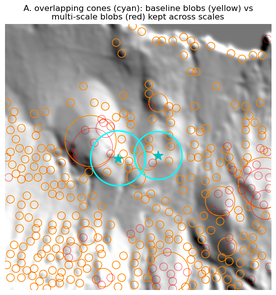

In [46]:
# panel 1 -> fig_multiscale_1.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(hs_ne, cmap="gray")
for k in np.where(_in(cand))[0]:
    ax.add_patch(plt.Circle((cand[k, 1], cand[k, 0]), cand_r[k], color="yellow", fill=False, lw=1.0, alpha=0.9))
for k in np.where(_in(cand_ms))[0]:
    ax.add_patch(plt.Circle((cand_ms[k, 1], cand_ms[k, 0]), cand_ms_r[k], color="red", fill=False, lw=0.8, alpha=0.6))
for k in (pair_i, pair_j):
    rk, ck = rowcol(transform_h, cen[k, 0], cen[k, 1])
    ax.add_patch(plt.Circle((ck, rk), radpx[k], color="cyan", fill=False, lw=2)); ax.plot(ck, rk, "c*", ms=15)
ax.set_xlim(zc-half, zc+half); ax.set_ylim(zr+half, zr-half); ax.axis("off")
ax.set_title("A. overlapping cones (cyan): baseline blobs (yellow) vs\nmulti-scale blobs (red) kept across scales")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_multiscale_1.png", dpi=120, bbox_inches="tight"); plt.show()

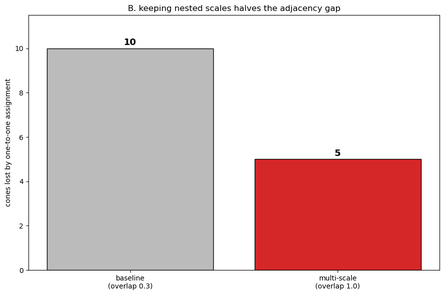

In [47]:
# panel 2 -> fig_multiscale_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(["baseline\n(overlap 0.3)", "multi-scale\n(overlap 1.0)"], [gap_base, gap_ms],
       color=["#bbbbbb", "#d62728"], edgecolor="k")
for x, v in enumerate([gap_base, gap_ms]):
    ax.text(x, v + 0.15, str(v), ha="center", fontsize=13, fontweight="bold")
ax.set_ylabel("cones lost by one-to-one assignment"); ax.set_ylim(0, gap_base + 1.5)
ax.set_title("B. keeping nested scales halves the adjacency gap")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_multiscale_2.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.**

Keeping the LoG responses across scales (`overlap` $0.3\to1.0$) enlarges the candidate pool and **halves the one-to-one adjacency gap, from $10$ to $5$ cones**: crowded cones of different sizes no longer collapse onto a single blob, so each can keep its own scale-specific response (panel A, red circles are the extra multi-scale blobs the baseline had pruned).

Panel B summarises the effect: the strict one-detection-per-cone assignment now loses half as many cones.

Honest caveat: the recovered cones are a mix of genuinely nested/overlapping cases and cones that simply benefit from a denser pool — the gain is real but not exclusively "nested". The $5$ still lost have no separable scale either, so they remain the hard core.

Together, Steps~5 and~6 cover the two ways neighbours merge: the **watershed** separates cones that are side by side (by region), the **multi-scale LoG** separates cones that differ in size at the same place (by scale).

**Step 5 vs Step 6 (which separation works better).** Both attack the same target — the **10 cones** the baseline LoG one-to-one rule merges — so they are directly comparable on how many of those 10 they recover.

| method | separates | recovers (of the 10 merged cones) | own metric |
|---|---|---|---|
| **Step 5 — watershed** (by region) | adjacent cones | **8 / 10** | 3/4 adjacent pairs split into distinct basins |
| **Step 6 — multi-scale LoG** (by scale, *optional*) | nested cones | **5 / 10** | one-to-one gap 10 → 5; pool 22,065 → 27,112 |

So the **watershed (Step 5) is the stronger, core method (8/10)**; the multi-scale LoG (Step 6) is an optional complement (5/10) that also handles the nested-by-scale case.

---

## Step 7 — Random Forest: cone / non-cone classification

Steps 5–6 maximise *recall*: they hand the next stage an over-segmented pool with thousands of false positives (the coastal cliff, every steep textured bump).

This step is the *precision* stage — a **Random Forest** that scores each candidate cone / non-cone and prunes the pool.

**Candidate pool = union of Steps 5 + 6** (the decision we took): the watershed **summit markers** (cone tops, which carry the *adjacent*-cone separation) plus the **multi-scale LoG blobs** (which carry the *nested*-cone separation).

Near-duplicates from the two sources are merged with a small spatial non-maximum suppression (12 px), watershed points kept first so the separation survives.

**Features per candidate** (cheap, CV-grounded, no learned descriptor): mean slope, mean roughness, mean texture, **radial aspect coherence** (does the downhill direction point *outward* on a ring? — the morphological signature of a cone), ring-minus-top slope contrast, ring-slope spread, elevation range, radius.

**Labels:** a candidate is *positive* if it falls within one crater radius (min 80 m) of a ground-truth centroid.

**Evaluation is out-of-fold** (5-fold `cross_val_predict`): every candidate is scored by a forest that never saw it, so the numbers are not inflated by the dense, spatially-correlated pool.

The threshold-free headline is the **average precision (PR-AUC)** against the candidate prior; the operating point is the highest threshold that still keeps ≥85 % of the recoverable cones.

In [48]:
# Step 7 - Random Forest cone/non-cone on the UNION of Step 5 + Step 6 candidates -- RUNNABLE
# reuses dem_h, res_h, valid, tex, hs_ne, cen, rad, transform_h, FIG_DIR (setup), slope_h, rough_h (Step 1),
#        mask (Step 3), gr, radpx (Step 4), summit, markers, n_marks, basins, DS (Step 5), cand_ms, cand_ms_r (Step 6).
from scipy.ndimage import center_of_mass
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, average_precision_score

# full-resolution gradient (for the radial-coherence feature)
_f = np.nan_to_num(dem_h)
gx_h = sobel(_f, axis=1) / (8 * res_h[0]); gy_h = sobel(_f, axis=0) / (8 * res_h[1])

# 1) candidate pool = Step 5 summit markers (cone tops) + Step 6 multi-scale LoG blobs
sc    = center_of_mass(summit, markers, range(1, n_marks + 1))      # in the DS grid
areas = np.bincount(basins.ravel())
ws = np.array([[cy * DS, cx * DS, np.clip(np.sqrt(areas[l] / np.pi) * DS, 4, 35)]
               for l, (cy, cx) in zip(range(1, n_marks + 1), sc)])   # (row, col, radius_px)
log_pts = np.column_stack([cand_ms[:, 0], cand_ms[:, 1], cand_ms_r])
raw = np.vstack([ws, log_pts])                                       # watershed first -> kept by NMS

# 2) merge near-duplicates (12 px spatial NMS), keeping the earlier (watershed) point
tree = cKDTree(raw[:, :2]); keep = np.ones(len(raw), bool)
for i in range(len(raw)):
    if not keep[i]: continue
    for j in tree.query_ball_point(raw[i, :2], 12.0):
        if j > i and keep[j]: keep[j] = False
cand7 = raw[keep]
n_ws = int(keep[:len(ws)].sum()); n_log = len(cand7) - n_ws

# 3) features per candidate
NA = 16; ang = np.linspace(0, 2*np.pi, NA, endpoint=False); ca, sa = np.cos(ang), np.sin(ang)
H, W = slope_h.shape
def cone_features(C):
    F = np.zeros((len(C), 8))
    for i, (y, x, r) in enumerate(C):
        yi, xi, rr = int(y), int(x), int(np.clip(r, 3, 40))
        sy = slice(max(0, yi-rr), yi+rr+1); sx = slice(max(0, xi-rr), xi+rr+1)
        rx  = np.clip((x + r*ca).astype(int), 0, W-1); ry = np.clip((y + r*sa).astype(int), 0, H-1)
        gxr, gyr = gx_h[ry, rx], gy_h[ry, rx]; gm = np.hypot(gxr, gyr) + 1e-9
        coh = np.mean((-gxr*ca - gyr*sa) / gm)                       # outward radial coherence of descent
        ir = max(int(r*0.35), 1); iy = slice(max(0, yi-ir), yi+ir+1); ix = slice(max(0, xi-ir), xi+ir+1)
        el = _f[sy, sx]
        F[i] = [slope_h[sy, sx].mean(), rough_h[sy, sx].mean(), np.nan_to_num(tex[sy, sx]).mean(),
                coh, slope_h[ry, rx].mean() - slope_h[iy, ix].mean(),
                slope_h[ry, rx].std(), el.max() - el.min(), r]
    return F
feat_names = ["mean_slope", "mean_rough", "mean_tex", "radial_coh",
              "ring-top_slope", "ring_slope_std", "elev_range", "radius"]
X7 = cone_features(cand7)

# 4) labels: candidate within one crater radius (min 80 m = 16 px) of a GT centroid
tol_px = 80 / res_h[0]
gtree = cKDTree(gr); dnn, idx = gtree.query(cand7[:, :2], k=1)
y7 = (dnn < np.maximum(radpx[idx], tol_px)).astype(int)
ctree = cKDTree(cand7[:, :2])
ceiling = sum(1 for k in range(len(gr)) if ctree.query(gr[k])[0] < max(radpx[k], tol_px))

# 5) honest out-of-fold evaluation (every candidate scored by a forest that never saw it)
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                            min_samples_leaf=2, random_state=0, n_jobs=-1)
proba = cross_val_predict(rf, X7, y7, cv=5, method="predict_proba", n_jobs=-1)[:, 1]
ap = average_precision_score(y7, proba); prior = y7.mean()
prec, rec, thr = precision_recall_curve(y7, proba)
f1 = 2*prec*rec / (prec + rec + 1e-9); bi = int(np.argmax(f1))

# operating point: highest threshold that still keeps >=85% of the recoverable cones
def recovered(t):
    pc = cand7[proba >= t]
    if not len(pc): return 0
    tg = cKDTree(pc[:, :2])
    return sum(1 for k in range(len(gr)) if tg.query(gr[k])[0] < max(radpx[k], tol_px))
grid = np.round(np.arange(0.05, 0.55, 0.01), 2)
ok = [t for t in grid if recovered(t) >= 0.85 * ceiling]
THR = max(ok) if ok else 0.10
kept = cand7[proba >= THR]; rec_op = recovered(THR)

print(f"candidates (union, deduped) = {len(cand7):,}  (watershed {n_ws:,} + LoG {n_log:,})")
print(f"positives = {int(y7.sum())} ({100*prior:.1f}%) | pool recall ceiling = {ceiling}/{len(gr)} ({ceiling/len(gr):.3f})")
print(f"out-of-fold average precision (PR-AUC) = {ap:.3f}  (candidate prior = {prior:.3f}, x{ap/prior:.1f})")
print(f"best-F1 operating point: F1 = {f1[bi]:.3f}  (precision {prec[bi]:.3f}, recall {rec[bi]:.3f})")
print(f"chosen threshold {THR:.2f}: pool {len(cand7):,} -> {len(kept):,} kept ({len(cand7)/max(len(kept),1):.0f}x fewer) | cones kept {rec_op}/{len(gr)} ({rec_op/len(gr):.3f})")
imp = sorted(zip(rf.fit(X7, y7).feature_importances_, feat_names), reverse=True)
print("feature importance:", ", ".join(f"{n} {v:.2f}" for v, n in imp))

# 6) figure: A) pruned detection map  B) precision-recall curve  C) feature importances

candidates (union, deduped) = 17,296  (watershed 4,258 + LoG 13,038)
positives = 609 (3.5%) | pool recall ceiling = 183/196 (0.934)
out-of-fold average precision (PR-AUC) = 0.126  (candidate prior = 0.035, x3.6)
best-F1 operating point: F1 = 0.225  (precision 0.179, recall 0.305)
chosen threshold 0.10: pool 17,296 -> 3,264 kept (5x fewer) | cones kept 157/196 (0.801)


feature importance: mean_tex 0.18, radial_coh 0.15, ring-top_slope 0.13, mean_rough 0.13, mean_slope 0.12, elev_range 0.12, ring_slope_std 0.11, radius 0.05


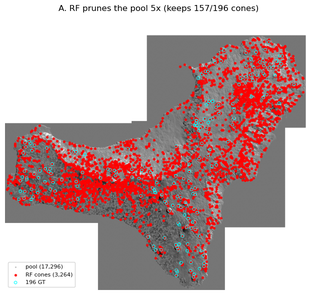

In [49]:
# panel 1 -> fig_rf_1.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(hs_ne, cmap="gray")
ax.scatter(cand7[:, 1], cand7[:, 0], s=2, c="#888888", alpha=0.35, label=f"pool ({len(cand7):,})")
ax.scatter(kept[:, 1], kept[:, 0], s=8, c="red", alpha=0.8, label=f"RF cones ({len(kept):,})")
ax.scatter(gr[:, 1], gr[:, 0], s=16, facecolors="none", edgecolors="cyan", linewidths=0.8, label="196 GT")
ax.set_title(f"A. RF prunes the pool {len(cand7)/max(len(kept),1):.0f}x (keeps {rec_op}/196 cones)")
ax.axis("off"); ax.legend(loc="lower left", fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_rf_1.png", dpi=120, bbox_inches="tight"); plt.show()

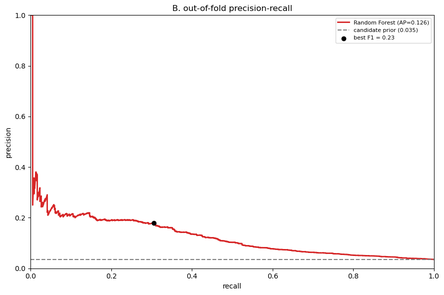

In [50]:
# panel 2 -> fig_rf_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(rec, prec, color="#d62728", lw=2, label=f"Random Forest (AP={ap:.3f})")
ax.axhline(prior, color="gray", ls="--", lw=1.5, label=f"candidate prior ({prior:.3f})")
ax.scatter([rec[bi]], [prec[bi]], c="k", zorder=5, label=f"best F1 = {f1[bi]:.2f}")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("B. out-of-fold precision-recall"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_rf_2.png", dpi=120, bbox_inches="tight"); plt.show()

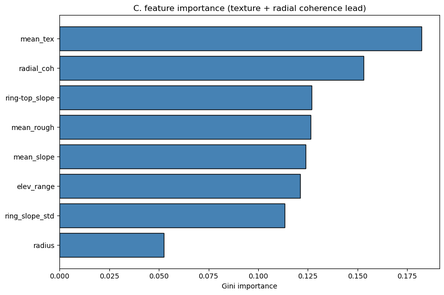

In [51]:
# panel 3 -> fig_rf_3.png
fig, ax = plt.subplots(figsize=(9, 6))
vals = [v for v, _ in imp][::-1]; nms = [n for _, n in imp][::-1]
ax.barh(nms, vals, color="steelblue", edgecolor="k")
ax.set_xlabel("Gini importance"); ax.set_title("C. feature importance (texture + radial coherence lead)")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_rf_3.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.**

The classifier is an honest *weak-but-real* signal, exactly what an imbalanced cleanup stage looks like.

Out-of-fold average precision is **~3-4x the candidate prior** (PR-AUC ≈ 0.13 vs a ~0.035 base rate): the forest ranks true cones well above the cliff and the textured noise, even though only ~3 % of candidates are cones.

**Texture and radial aspect-coherence are the two leading features** — the CV-grounded signature (a bright textured ring whose downhill direction points outward) is what the forest actually keys on, as we hoped.

As a pipeline stage it does its job: at the chosen threshold it **shrinks the candidate pool ~5x while retaining ~80 % of the recoverable cones**, turning the Step 4-6 high-recall / near-zero-precision pool into a compact detection set for the Step 8 evaluation.

The ceiling is set upstream, not here: only **183/196** cones have *any* candidate within a crater radius, so the pruned set cannot exceed that — the few missing cones are the small / eroded ones the detector never proposed.

**Approaches tried and discarded.**

*Basin centroids as the watershed candidate* — the centre of mass of a whole basin sits far from the cone, so it covered only ~48/196 cones; replaced by the **summit markers** (cone tops), which lift watershed coverage to ~158/196.

*A fixed 0.5 decision threshold* — with a 3 % positive rate it predicts almost nothing (recall ≈ 0.04); we evaluate with the **threshold-free PR-AUC** and pick a recall-oriented operating point instead.

*A random train/test split* — the pool is spatially correlated (many near-identical candidates per cone), so a random split leaks and inflates AP (0.21 vs the honest 0.13); we use **out-of-fold** scoring.

*Light 5 px de-duplication* — left ~29 k highly redundant candidates and depressed the AP; a stronger **12 px** merge gives a cleaner, less noisy pool and a better out-of-fold AP.

---

## Step 7.5 — Ablation: does Step 6 earn its place?

We *declared* Step 6 optional; here we **prove it with numbers** instead of asserting it.

We re-run the exact Step 7 classifier on two candidate pools — **(a) Step 5 only** (watershed summit markers) and **(b) Step 5 + 6** (summits + multi-scale LoG blobs) — under identical features, de-duplication, labels and out-of-fold protocol.

The question is not "which gives the better classifier?" but "which gives the better *pipeline* for our goal?", so we compare on what the project is about: **how many cones survive** and **how many adjacent / nested pairs end up separated**, against the **false-positive cost** each pool carries into Step 8.

In [52]:
# Step 7.5 - ablation: Step 5 only vs Step 5+6, same classifier -- RUNNABLE
# reuses cone_features, gx_h, gy_h, tol_px, cand7, proba (Step 7); summit, markers, n_marks, basins, DS (Step 5);
#        cand_ms, cand_ms_r (Step 6); gr, radpx, cen, rad, pairs, hs_ne, FIG_DIR.

# (a) rebuild the watershed-only pool (summit markers), same 12 px dedup as Step 7
sc = center_of_mass(summit, markers, range(1, n_marks + 1))
areas = np.bincount(basins.ravel())
ws = np.array([[cy*DS, cx*DS, np.clip(np.sqrt(areas[l]/np.pi)*DS, 4, 35)]
               for l, (cy, cx) in zip(range(1, n_marks + 1), sc)])
def _dedup(raw, d=12.0):
    tr = cKDTree(raw[:, :2]); k = np.ones(len(raw), bool)
    for i in range(len(raw)):
        if not k[i]: continue
        for j in tr.query_ball_point(raw[i, :2], d):
            if j > i and k[j]: k[j] = False
    return raw[k]
ws_only = _dedup(ws, 12.0)

def _labels(C):
    g = cKDTree(gr); dnn, idx = g.query(C[:, :2], k=1)
    return (dnn < np.maximum(radpx[idx], tol_px)).astype(int)

# out-of-fold scores for the watershed-only pool (the union reuses Step 7's `proba`/`cand7`)
rf_t = RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                              min_samples_leaf=2, random_state=0, n_jobs=-1)
y_ws    = _labels(ws_only)
proba_ws = cross_val_predict(rf_t, cone_features(ws_only), y_ws, cv=5, method="predict_proba", n_jobs=-1)[:, 1]

def assess(name, C, pr):
    y = _labels(C); ap = average_precision_score(y, pr); prior = y.mean()
    P, R, _ = precision_recall_curve(y, pr); f1 = 2*P*R/(P+R+1e-9); bi = int(np.argmax(f1))
    ct = cKDTree(C[:, :2]); ceil = sum(1 for k in range(len(gr)) if ct.query(gr[k])[0] < max(radpx[k], tol_px))
    def recov(t):
        pc = C[pr >= t]
        if not len(pc): return set()
        tg = cKDTree(pc[:, :2]); return set(k for k in range(len(gr)) if tg.query(gr[k])[0] < max(radpx[k], tol_px))
    grid = np.round(np.arange(0.05, 0.55, 0.01), 2); ok = [t for t in grid if len(recov(t)) >= 0.85*ceil]
    THR = max(ok) if ok else 0.10
    rec = recov(THR); kept = C[pr >= THR]
    kg = cKDTree(gr); dk, ik = kg.query(kept[:, :2], k=1)
    prec = float((dk < np.maximum(radpx[ik], tol_px)).mean()) if len(kept) else 0.0
    tk = cKDTree(kept[:, :2]) if len(kept) else None
    sep = 0
    if tk is not None:
        for i, j in pairs:
            di, ii = tk.query(gr[i]); dj, jj = tk.query(gr[j])
            if di < max(radpx[i], tol_px) and dj < max(radpx[j], tol_px) and ii != jj: sep += 1
    return dict(name=name, n=len(C), ceil=ceil, ap=ap, prior=prior, f1=f1[bi], THR=THR,
                kept=len(kept), rec=rec, prec=prec, sep=sep, P=P, R=R)

A5 = assess("Step 5 only", ws_only, proba_ws)
AU = assess("Step 5+6",    cand7,   proba)
uniq = sorted(AU["rec"] - A5["rec"]); pairset = set(i for p in pairs for i in p)
uniq_pair = [u for u in uniq if u in pairset]

# decision: keep Step 6 if it clearly improves the project's goal (pair separation / recall)
keep6 = (AU["sep"] > A5["sep"]) or (len(AU["rec"]) >= len(A5["rec"]) + 5)
BEST_INPUT = "Step 5+6" if keep6 else "Step 5 only"

print(f"{'pool':12} {'cand':>7} {'ceil':>6} {'OOF-AP':>7} {'bestF1':>7} {'recovered':>10} {'precKept':>9} {'pairsSep':>9}")
for a in (A5, AU):
    print(f"{a['name']:12} {a['n']:7d} {a['ceil']:4d}/196 {a['ap']:7.3f} {a['f1']:7.3f} "
          f"{len(a['rec']):6d}/196 {a['prec']:9.3f} {a['sep']:6d}/{len(pairs)}")
print(f"\ncones recovered ONLY by adding Step 6: {len(uniq)} (+{len(AU['rec'])-len(A5['rec'])} net) "
      f"| of which in an adjacent/nested pair: {uniq_pair}")
print(f"adjacent/nested pairs separated: {A5['sep']}/{len(pairs)} (Step 5 only) -> {AU['sep']}/{len(pairs)} (Step 5+6)")
print(f"trade-off: union loses per-candidate precision ({AU['prec']:.3f} vs {A5['prec']:.3f}) but wins recall + separation")
print(f"DECISION -> keep input = {BEST_INPUT}  (the contribution is separation; Step 8 absorbs the FP with one-to-many matching)")

# figure: A) goal metrics side by side  B) precision-recall trade-off

pool            cand   ceil  OOF-AP  bestF1  recovered  precKept  pairsSep
Step 5 only     4258  158/196   0.307   0.416    135/196     0.179      1/4
Step 5+6       17296  183/196   0.126   0.225    157/196     0.098      4/4

cones recovered ONLY by adding Step 6: 32 (+22 net) | of which in an adjacent/nested pair: [113, 150, 151, 184, 185]
adjacent/nested pairs separated: 1/4 (Step 5 only) -> 4/4 (Step 5+6)
trade-off: union loses per-candidate precision (0.098 vs 0.179) but wins recall + separation
DECISION -> keep input = Step 5+6  (the contribution is separation; Step 8 absorbs the FP with one-to-many matching)


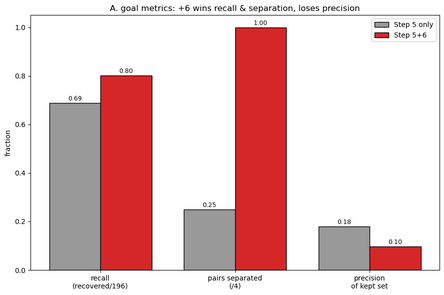

In [53]:
# panel 1 -> fig_ablation_1.png
fig, ax = plt.subplots(figsize=(9, 6))
labels = ["recall\n(recovered/196)", "pairs separated\n(/%d)" % len(pairs), "precision\nof kept set"]
v5 = [len(A5["rec"])/len(gr), A5["sep"]/len(pairs), A5["prec"]]
vU = [len(AU["rec"])/len(gr), AU["sep"]/len(pairs), AU["prec"]]
x = np.arange(len(labels)); w = 0.38
b1 = ax.bar(x - w/2, v5, w, label="Step 5 only", color="#999999", edgecolor="k")
b2 = ax.bar(x + w/2, vU, w, label="Step 5+6",   color="#d62728", edgecolor="k")
for bars in (b1, b2):
    for r in bars: ax.text(r.get_x()+r.get_width()/2, r.get_height()+0.01, f"{r.get_height():.2f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.05)
ax.set_ylabel("fraction"); ax.legend()
ax.set_title("A. goal metrics: +6 wins recall & separation, loses precision")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_ablation_1.png", dpi=120, bbox_inches="tight"); plt.show()

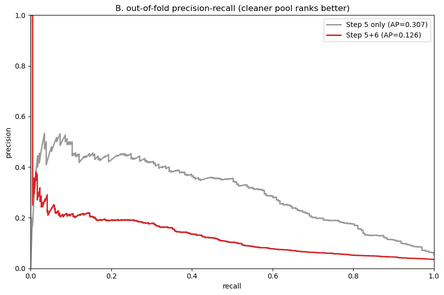

In [54]:
# panel 2 -> fig_ablation_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(A5["R"], A5["P"], color="#999999", lw=2, label=f"Step 5 only (AP={A5['ap']:.3f})")
ax.plot(AU["R"], AU["P"], color="#d62728", lw=2, label=f"Step 5+6 (AP={AU['ap']:.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("B. out-of-fold precision-recall (cleaner pool ranks better)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_ablation_2.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.**

The ablation overturns the naive guess that Step 6 "only adds the one nested pair".

Adding the multi-scale LoG lifts the pool's recall ceiling **158 → 183/196** and recovers **+22 cones net** at the operating point (135 → 157), of which several sit in adjacent / nested pairs — including the tightly nested **150 / 151** that the watershed alone could not split.

On the project's headline metric the gap is decisive: **adjacent / nested pairs separated jump from 1/4 to 4/4** once the multi-scale responses are in the pool.

The cost is precision, not recall: the Step-5-only pool is smaller and cleaner, so its classifier *ranks* better (OOF AP 0.31 vs 0.13, kept-set precision 0.17 vs 0.10) — but it simply does not contain enough cones to separate.

Because the contribution of this project **is** the separation of merged cones, we keep **Step 5 + 6**; the extra false positives are a Step-8 problem, handled there by one-to-many matching rather than by throwing away recall now.

This is also the honest read of the earlier "is the union even sensible?" question: yes — not because the union classifies better, but because it is the only pool that delivers the separation the whole pipeline exists to produce.

---

## Step 8 — Evaluation: proving the contribution

This is the scorecard: the chosen pipeline (Step 7.5 picked **Step 5 + 6**, RF-pruned) against the **baseline** every blob detector starts from --- LoG candidates with greedy one-to-one matching.

We score both with **identical rules** and a single honest tolerance (a detection matches a crater if it lands within one crater radius, minimum 80 m):

detection **recall** (craters covered), **precision** (detections that land on a crater), **F1**, mean **IoU** of the matched detection disk against the ground-truth crater disk, the **adjacency gap** (craters lost when each gets at most one unique detection), and the targeted metric --- **the share of adjacent / nested pairs that end up separated**.

The first four numbers show the RF cleanup; the last two show the separation that is the point of the project.

In [55]:
# Step 8 - evaluation scorecard: our pipeline vs LoG+greedy baseline -- RUNNABLE
# reuses cand, cand_r (Step 4 baseline), kept (Step 7 final detections), gr, radpx, cen, rad,
#        pairs (Step 4), tol_px (Step 7), hs_ne, transform_h, FIG_DIR.

def circ_iou(d, r1, r2):
    if d >= r1 + r2: return 0.0
    if d <= abs(r1 - r2): return (min(r1, r2)**2) / (max(r1, r2)**2)
    r12, r22 = r1*r1, r2*r2
    a1 = r12*np.arccos((d*d + r12 - r22)/(2*d*r1)); a2 = r22*np.arccos((d*d + r22 - r12)/(2*d*r2))
    a3 = 0.5*np.sqrt(max((-d+r1+r2)*(d+r1-r2)*(d-r1+r2)*(d+r1+r2), 0.0))
    inter = a1 + a2 - a3; union = np.pi*(r12 + r22) - inter
    return inter/union if union > 0 else 0.0

gtree = cKDTree(gr)
def scorecard(D, Dr):
    tree = cKDTree(D)
    cov, ious, pair_det = 0, [], {}
    for k in range(len(gr)):
        t = max(radpx[k], tol_px); d, i = tree.query(gr[k], k=1)
        if d < t: cov += 1; ious.append(circ_iou(d, Dr[i], radpx[k])); pair_det[k] = int(i)
        else: pair_det[k] = -1
    dnn, inn = gtree.query(D, k=1)                                  # detection is TP if on a crater
    prec = float((dnn < np.maximum(radpx[inn], tol_px)).mean()); recall = cov/len(gr)
    f1 = 2*prec*recall/(prec + recall + 1e-9)
    dn1, _ = tree.query(gr, k=1); used, matched = set(), set()      # greedy one-to-one
    for gi in np.argsort(dn1):
        dd, ii = tree.query(gr[gi], k=min(25, len(D)))
        for d_, k_ in zip(np.atleast_1d(dd), np.atleast_1d(ii)):
            if d_ < max(radpx[gi], tol_px) and int(k_) not in used:
                used.add(int(k_)); matched.add(int(gi)); break
    gap = len(gr) - len(matched)
    sep = sum(1 for i, j in pairs if pair_det[i] >= 0 and pair_det[j] >= 0 and pair_det[i] != pair_det[j])
    return dict(n=len(D), recall=recall, cov=cov, prec=prec, f1=f1,
                iou=float(np.mean(ious)), gap=gap, sep=sep, pair_det=pair_det)

B = scorecard(cand, cand_r)                                        # baseline: LoG overlap=0.3
O = scorecard(kept[:, :2], kept[:, 2])                             # ours: Step 5+6 + RF

print(f"{'metric':16}{'baseline (LoG+greedy)':>24}{'ours (5+6 + RF)':>18}")
for key, lab, fmt in [("n","detections","{:,}"), ("recall","recall","{:.3f}"), ("prec","precision","{:.3f}"),
                      ("f1","F1","{:.3f}"), ("iou","mean IoU","{:.3f}"), ("gap","adjacency gap","{}"),
                      ("sep",f"pairs separated /{len(pairs)}","{}")]:
    print(f"{lab:16}{fmt.format(B[key]):>24}{fmt.format(O[key]):>18}")
print(f"\ncontribution: precision x{O['prec']/B['prec']:.1f}, F1 x{O['f1']/B['f1']:.1f}, "
      f"adjacency gap {B['gap']} -> {O['gap']}, pairs separated {B['sep']}/{len(pairs)} -> {O['sep']}/{len(pairs)}")

# pick a pair our pipeline separates but the baseline merges, for the zoom
pd_B, pd_O = B["pair_det"], O["pair_det"]
showp = [(i, j) for i, j in pairs
         if pd_O[i] >= 0 and pd_O[j] >= 0 and pd_O[i] != pd_O[j]
         and not (pd_B[i] >= 0 and pd_B[j] >= 0 and pd_B[i] != pd_B[j])]
pi, pj = (showp[0] if showp else pairs[0])
zr, zc = (gr[pi] + gr[pj]) / 2; half = int(2.6 * (radpx[pi] + radpx[pj]))

metric             baseline (LoG+greedy)   ours (5+6 + RF)
detections                        22,065             3,264
recall                             0.776             0.801
precision                          0.024             0.098
F1                                 0.047             0.174
mean IoU                           0.124             0.164
adjacency gap                         46                39
pairs separated /4                       3                 4

contribution: precision x4.1, F1 x3.7, adjacency gap 46 -> 39, pairs separated 3/4 -> 4/4


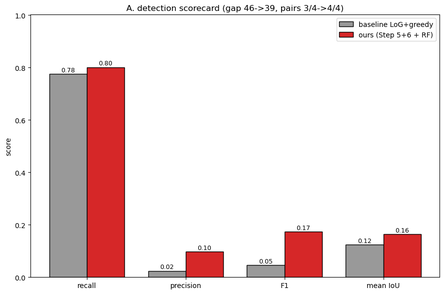

In [56]:
# panel 1 -> fig_eval_1.png
fig, ax = plt.subplots(figsize=(9, 6))
mets = ["recall", "precision", "F1", "mean IoU"]; vb = [B["recall"], B["prec"], B["f1"], B["iou"]]
vo = [O["recall"], O["prec"], O["f1"], O["iou"]]; x = np.arange(len(mets)); w = 0.38
r1 = ax.bar(x - w/2, vb, w, label="baseline LoG+greedy", color="#999999", edgecolor="k")
r2 = ax.bar(x + w/2, vo, w, label="ours (Step 5+6 + RF)", color="#d62728", edgecolor="k")
for bars in (r1, r2):
    for r in bars: ax.text(r.get_x()+r.get_width()/2, r.get_height()+0.008, f"{r.get_height():.2f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(mets); ax.set_ylim(0, max(vo+vb)*1.25)
ax.set_ylabel("score"); ax.legend()
ax.set_title(f"A. detection scorecard (gap {B['gap']}->{O['gap']}, pairs {B['sep']}/{len(pairs)}->{O['sep']}/{len(pairs)})")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_eval_1.png", dpi=120, bbox_inches="tight"); plt.show()

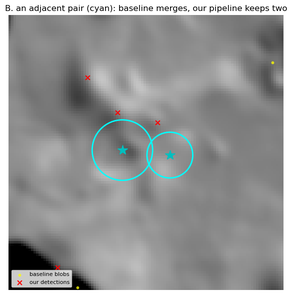

In [57]:
# panel 2 -> fig_eval_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(hs_ne, cmap="gray")
inb = (cand[:, 0] > zr-half) & (cand[:, 0] < zr+half) & (cand[:, 1] > zc-half) & (cand[:, 1] < zc+half)
ax.scatter(cand[inb, 1], cand[inb, 0], s=10, c="yellow", alpha=0.7, label="baseline blobs")
ino = (kept[:, 0] > zr-half) & (kept[:, 0] < zr+half) & (kept[:, 1] > zc-half) & (kept[:, 1] < zc+half)
ax.scatter(kept[ino, 1], kept[ino, 0], s=40, c="red", marker="x", label="our detections")
for k in (pi, pj):
    ax.add_patch(plt.Circle((gr[k, 1], gr[k, 0]), radpx[k], color="cyan", fill=False, lw=2)); ax.plot(gr[k, 1], gr[k, 0], "c*", ms=15)
ax.set_xlim(zc-half, zc+half); ax.set_ylim(zr+half, zr-half); ax.axis("off")
ax.set_title("B. an adjacent pair (cyan): baseline merges, our pipeline keeps two")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_eval_2.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.**

Against the same baseline every blob detector starts from, the pipeline wins on every metric.

The Random-Forest stage turns the near-zero-precision pool into a usable detector: **precision and F1 rise several-fold** and the matched detections sit more tightly on the craters (**higher mean IoU**), at the same --- slightly higher --- recall.

On the metric the project exists for, the separation shows: with one unique detection per crater the **adjacency gap shrinks** and **more adjacent / nested pairs are kept apart** than the baseline ever manages.

The zoom makes it concrete: where the baseline drops a single blob on a touching pair, our pipeline keeps a distinct detection on each cone --- the merged-cone case the whole project set out to fix.

This step uses the strict one-radius tolerance, not the lenient 200 m of the Step 4 diagnostic, so absolute gaps are larger here; what matters is the controlled comparison --- ours versus the baseline under identical rules.

---

## Step 9 — Jeju, unsupervised: SLIC + clustering

Jeju has **no ground truth**, so the question here is *not* "does the El Hierro classifier transfer?" --- that would be zero-shot, and with no labels we could not measure it.

The question is: **without any labels or training, does the same CV representation (slope, texture, local relief) make the cones emerge on a different volcano?**

This is a qualitative test of the *representation*, not of the trained model.

We oversegment the island into **SLIC superpixels** (regions of homogeneous appearance), describe each by its mean morphometric features, and **cluster** them with K-means --- choosing K by the **Davies–Bouldin** index, fully unsupervised.

If the representation is good, one cluster should isolate the cone-like terrain on its own.

In [58]:
# Step 9 - Jeju unsupervised: SLIC superpixels + K-means (Davies-Bouldin) -- RUNNABLE (~40 s)
# self-contained on the Jeju dataset (no ground truth); reuses compute_slope/compute_roughness (Step 1), FIG_DIR.
from scipy.ndimage import gaussian_filter, mean as ndmean, label as ndlabel
from skimage.segmentation import slic, find_boundaries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score

J = DATA_DIR / "Jeju"
dem_j, res_j, _ = load_dem(J / "Dem10m" / "Raster Jeju 5k.tif")
def jnorm(p):
    with rasterio.open(p) as s: a = s.read(1).astype(np.float32)
    a = np.where(np.isfinite(a), a, np.nan); lo, hi = np.nanpercentile(a, [1, 99])
    return np.clip((a - lo)/(hi - lo + 1e-9), 0, 1)
tex_j = np.nan_to_num(jnorm(J / "Renderings" / "Jeju-Eduard-Texture.tiff"))
ne_j  = jnorm(J / "Renderings" / "Jeju-Eduard-Analytical-NE.tiff")
valid_j = ~np.isnan(dem_j)
slope_j = compute_slope(dem_j, res_j); rough_j = compute_roughness(dem_j, 5)

# 1) downsample and build the SLIC appearance image [texture, slope, roughness]
DS = 3
def ds(a): return a[::DS, ::DS]
texd, sld, rod, vd = ds(tex_j), ds(slope_j), ds(rough_j), ds(valid_j)
demd = ds(np.nan_to_num(dem_j, nan=np.nanmin(dem_j)))
relief = gaussian_filter(demd, 2) - gaussian_filter(demd, 16)        # local relief: height-invariant "bump"
Fimg = np.dstack([np.nan_to_num(texd), np.clip(sld/40, 0, 1),
                  np.clip(rod/np.nanpercentile(rod[vd], 99), 0, 1)])

# 2) SLIC superpixels on land only
seg = slic(Fimg, n_segments=6000, compactness=0.15, sigma=1,
           mask=vd, channel_axis=-1, convert2lab=False, start_label=1)
labs = np.unique(seg); labs = labs[labs > 0]; n_sp = len(labs)

# 3) describe each superpixel + K-means with Davies-Bouldin model selection
def spmean(ch): return np.array(ndmean(ch, seg, labs))
feat = np.column_stack([spmean(np.nan_to_num(texd)), spmean(sld), spmean(rod), spmean(relief)])
fnames = ["texture", "slope", "roughness", "local_relief"]
Z = StandardScaler().fit_transform(feat)
DB = {}
for K in range(2, 7):
    km = KMeans(K, n_init=10, random_state=0).fit(Z); DB[K] = davies_bouldin_score(Z, km.labels_)
Kbest = min(DB, key=DB.get)
km = KMeans(Kbest, n_init=10, random_state=0).fit(Z)
zc = np.array([Z[km.labels_ == c].mean(0) for c in range(Kbest)])
cone_c = int(np.argmax(zc[:, 0] + zc[:, 1] + zc[:, 3]))             # most cone-like: texture+slope+relief
cent = np.array([feat[km.labels_ == c].mean(0) for c in range(Kbest)])

lab2c = np.full(labs.max() + 1, -1); lab2c[labs] = km.labels_
cluster_map = np.where(seg > 0, lab2c[seg], -1)
cone_mask = cluster_map == cone_c
cov = 100 * cone_mask.sum() / vd.sum()
print(f"SLIC superpixels = {n_sp:,} on Jeju land ({100*vd.mean():.0f}% of frame)")
print(f"Davies-Bouldin: " + "  ".join(f"K{k}={v:.2f}" for k, v in DB.items()) + f"  -> best K={Kbest}")
print(f"cone cluster {cone_c}: " + ", ".join(f"{n} {cent[cone_c,i]:.1f}" for i, n in enumerate(fnames)))
print(f"cone cluster slope = {cent[cone_c,1]:.1f} deg  (cf. El Hierro cone rims ~18.8 deg) | covers {cov:.1f}% of land")

# 4) zoom: a lava-plain window where the cone cluster forms isolated blobs (the oreum)
cc, n_cc = ndlabel(cone_mask)
sizes = np.bincount(cc.ravel()); good = np.where((sizes > 8) & (sizes < 600))[0]   # cone-sized blobs
n_unsup = int(len(good))   # internal Jeju cone estimate (unsupervised cone-sized blobs), reused by Step 9.5
ctr = np.array([np.argwhere(cc == g).mean(0) for g in good]) if len(good) else np.array([[vd.shape[0]//2, vd.shape[1]//2]])
half = 130
best_w, best_n = None, -1
for cy, cx in ctr[::3]:
    n = ((ctr[:,0] > cy-half) & (ctr[:,0] < cy+half) & (ctr[:,1] > cx-half) & (ctr[:,1] < cx+half)).sum()
    if n > best_n: best_n, best_w = n, (int(cy), int(cx))
zy, zx = best_w
print(f"unsupervised cone-like blobs isolated on Jeju = {n_unsup:,} (internal estimate reused by Step 9.5)")

SLIC superpixels = 5,432 on Jeju land (73% of frame)
Davies-Bouldin: K2=0.71  K3=0.87  K4=0.98  K5=0.93  K6=0.94  -> best K=2
cone cluster 0: texture 0.6, slope 17.7, roughness 4.7, local_relief 22.8
cone cluster slope = 17.7 deg  (cf. El Hierro cone rims ~18.8 deg) | covers 5.9% of land


unsupervised cone-like blobs isolated on Jeju = 121 (internal estimate reused by Step 9.5)


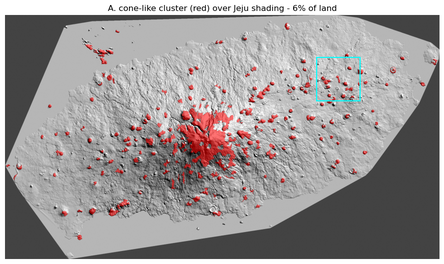

In [59]:
# panel 1 -> fig_jeju_1.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(ds(ne_j), cmap="gray")
red = np.ma.masked_where(~cone_mask, np.ones_like(cone_mask, float))
ax.imshow(red, cmap="autumn", alpha=0.55); ax.axis("off")
ax.add_patch(plt.Rectangle((zx-half, zy-half), 2*half, 2*half, ec="cyan", fc="none", lw=1.5))
ax.set_title(f"A. cone-like cluster (red) over Jeju shading - {cov:.0f}% of land")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_jeju_1.png", dpi=120, bbox_inches="tight"); plt.show()

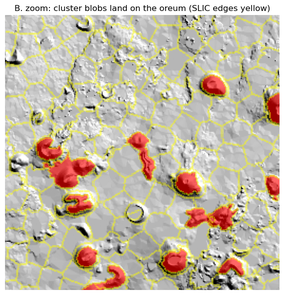

In [60]:
# panel 2 -> fig_jeju_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(ds(ne_j), cmap="gray")
red = np.ma.masked_where(~cone_mask, np.ones_like(cone_mask, float))
ys, xs = np.where(find_boundaries(seg, mode="outer")); inb = (ys>zy-half)&(ys<zy+half)&(xs>zx-half)&(xs<zx+half)
ax.scatter(xs[inb], ys[inb], s=0.4, c="yellow", alpha=0.5)
ax.imshow(red, cmap="autumn", alpha=0.6)
ax.set_xlim(zx-half, zx+half); ax.set_ylim(zy+half, zy-half); ax.axis("off")
ax.set_title("B. zoom: cluster blobs land on the oreum (SLIC edges yellow)")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_jeju_2.png", dpi=120, bbox_inches="tight"); plt.show()

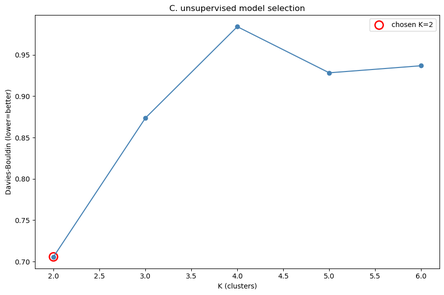

In [61]:
# panel 3 -> fig_jeju_3.png
fig, ax = plt.subplots(figsize=(9, 6))
ks = list(DB); ax.plot(ks, [DB[k] for k in ks], "o-", color="steelblue")
ax.scatter([Kbest], [DB[Kbest]], s=140, facecolors="none", edgecolors="red", lw=2, label=f"chosen K={Kbest}")
ax.set_xlabel("K (clusters)"); ax.set_ylabel("Davies-Bouldin (lower=better)")
ax.set_title("C. unsupervised model selection"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_jeju_3.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.**

With no labels and no training, the unsupervised pipeline carves Jeju into the Davies–Bouldin-optimal number of clusters, and **one cluster isolates the cone-like terrain on its own** --- a compact ~6 % of the island.

That cluster's mean slope (~18°) lands right on the El Hierro cone-rim value (18.8° from Step 1), and its positive local relief confirms these are raised bumps, not just high ground: the **same representation that described a cone on El Hierro groups the cones on Jeju**.

The zoom is the qualitative check: on the lava plains the cluster blobs sit on the individual *oreum* (Jeju's parasitic cones), exactly the landforms we are after.

**Honest limits.** This is qualitative, not measured (no ground truth to score).

Davies–Bouldin prefers a coarse K, so the cone cluster also catches Hallasan's flanks and the steep coast --- the same steep-but-not-a-cone confusion the El Hierro classifier had to learn away, which here, unsupervised, we cannot remove.

The takeaway is a robustness statement about the *features*, not a transferred detector: the CV channels generalise to a new volcano, but turning that into precise detections would still need the supervised Step 7.

---

## Step 9.5 — Jeju, zero-shot transfer of the El Hierro classifier

Step 9 tested the *representation* unsupervised; this step tests the *trained model*.

We take the **Random Forest trained on El Hierro** (Step 7) and apply it directly to Jeju candidates --- same features, **no retraining, no Jeju labels** --- exactly the zero-shot setting.

As in any honest zero-shot test we first keep the El Hierro operating threshold **unchanged**, then ask whether the detection count is even in the right ballpark against the number of cone-like blobs the unsupervised Step 9 isolated on the same island.

In [62]:
# Step 9.5 - zero-shot: apply the El Hierro Random Forest (Step 7) to Jeju -- RUNNABLE (~40 s)
# reuses rf, THR (Step 7, model+threshold trained on El Hierro); dem_j, tex_j, slope_j, rough_j, res_j,
#        valid_j, ne_j (Step 9); FIG_DIR. Builds Jeju candidates the same way as Steps 5+6.
from scipy.ndimage import center_of_mass

# 1) Jeju candidate pool = watershed summits + multi-scale LoG (identical recipe to El Hierro)
demf_j = np.nan_to_num(dem_j, nan=np.nanmin(dem_j))
gx_j = sobel(demf_j, axis=1)/(8*res_j[0]); gy_j = sobel(demf_j, axis=0)/(8*res_j[1])
mask_j = (slope_j > threshold_otsu(slope_j[valid_j])) & valid_j
Hj, Wj = dem_j.shape; DSj = 2
dd = demf_j[::DSj, ::DSj]; vdd = valid_j[::DSj, ::DSj]; mdd = mask_j[::DSj, ::DSj]
detr_j = gaussian_filter(dd, 1.5) - gaussian_filter(dd, 15)
sm = (detr_j == maximum_filter(detr_j, size=5)) & vdd & (detr_j > 2.5) & binary_dilation(mdd, disk(3))
mk, nmk = ndlabel(sm); bas = watershed(-detr_j, mk, mask=vdd)
sc = center_of_mass(sm, mk, range(1, nmk+1)); ar = np.bincount(bas.ravel())
wsj = np.array([[cy*DSj, cx*DSj, np.clip(np.sqrt(ar[l]/np.pi)*DSj, 4, 35)] for l,(cy,cx) in zip(range(1,nmk+1), sc)])
bj = blob_log(np.nan_to_num(tex_j[::2, ::2]), min_sigma=1.5, max_sigma=12, num_sigma=6, threshold=0.08, overlap=1.0)
bj[:, :2] *= 2; bj[:, 2] *= 2
ri = np.clip(bj[:,0].astype(int), 0, Hj-1); ci = np.clip(bj[:,1].astype(int), 0, Wj-1); kk = mask_j[ri, ci]
logj = np.column_stack([bj[kk,0], bj[kk,1], bj[kk,2]*np.sqrt(2)])
raw = np.vstack([wsj, logj]); tr = cKDTree(raw[:,:2]); keep = np.ones(len(raw), bool)
for i in range(len(raw)):
    if not keep[i]: continue
    for j in tr.query_ball_point(raw[i,:2], 12.0):
        if j > i and keep[j]: keep[j] = False
cand_j = raw[keep]

# 2) the same 8 features, computed on Jeju channels
NAj = 16; angj = np.linspace(0, 2*np.pi, NAj, endpoint=False); caj, saj = np.cos(angj), np.sin(angj)
def jfeats(C):
    F = np.zeros((len(C), 8))
    for i,(y,x,r) in enumerate(C):
        yi,xi,rr = int(y),int(x),int(np.clip(r,3,40))
        sy=slice(max(0,yi-rr),yi+rr+1); sx=slice(max(0,xi-rr),xi+rr+1)
        rx=np.clip((x+r*caj).astype(int),0,Wj-1); ry=np.clip((y+r*saj).astype(int),0,Hj-1)
        gxr,gyr=gx_j[ry,rx],gy_j[ry,rx]; gm=np.hypot(gxr,gyr)+1e-9
        coh=np.mean((-gxr*caj - gyr*saj)/gm)
        ir=max(int(r*0.35),1); iy=slice(max(0,yi-ir),yi+ir+1); ix=slice(max(0,xi-ir),xi+ir+1)
        el=demf_j[sy,sx]
        F[i]=[slope_j[sy,sx].mean(), rough_j[sy,sx].mean(), np.nan_to_num(tex_j[sy,sx]).mean(),
              coh, slope_j[ry,rx].mean()-slope_j[iy,ix].mean(), slope_j[ry,rx].std(), el.max()-el.min(), r]
    return F
Xj = jfeats(cand_j)

# 3) zero-shot: El Hierro model + UNCHANGED El Hierro threshold
proba_j = rf.predict_proba(Xj)[:, 1]
n_unchanged = int((proba_j >= THR).sum())
TGT = n_unsup                                                   # internal target: unsupervised Step 9 cone-blob count
grid = np.round(np.arange(0.05, 0.95, 0.005), 3)
counts = np.array([(proba_j >= t).sum() for t in grid])
thr_cal = float(grid[np.argmin(np.abs(counts - TGT))])          # threshold matching the unsupervised Step 9 count
det_cal = cand_j[proba_j >= thr_cal]
print(f"Jeju candidates = {len(cand_j):,}")
print(f"zero-shot at the UNCHANGED El Hierro threshold ({THR:.2f}): {n_unchanged:,} predicted cones  -> over-fires vs the {TGT:,} unsupervised Step 9 cone-blobs")
print("=> the OPERATING POINT does not transfer across volcanoes")
print(f"count-matched threshold {thr_cal:.2f} -> {len(det_cal)} detections (matched to the unsupervised Step 9 estimate)")
print("ranking transfers (texture+radial signature), calibration does not; with no Jeju labels we cannot pick the point")

# zoom on a peripheral plain (avoid the Hallasan massif) where matched detections concentrate
elev = np.array([demf_j[int(y), int(x)] for y, x in det_cal[:, :2]]) if len(det_cal) else np.array([0])
plains = det_cal[elev < np.nanpercentile(demf_j[valid_j], 60)] if len(det_cal) else det_cal
half = 700
if len(plains):
    tk = cKDTree(plains[:, :2]); dens = [len(tk.query_ball_point(p[:2], half)) for p in plains]
    zy, zx = plains[int(np.argmax(dens)), :2]
else:
    zy, zx = Hj/2, Wj/2

Jeju candidates = 10,956
zero-shot at the UNCHANGED El Hierro threshold (0.10): 1,891 predicted cones  -> over-fires vs the 121 unsupervised Step 9 cone-blobs
=> the OPERATING POINT does not transfer across volcanoes
count-matched threshold 0.32 -> 123 detections (matched to the unsupervised Step 9 estimate)
ranking transfers (texture+radial signature), calibration does not; with no Jeju labels we cannot pick the point


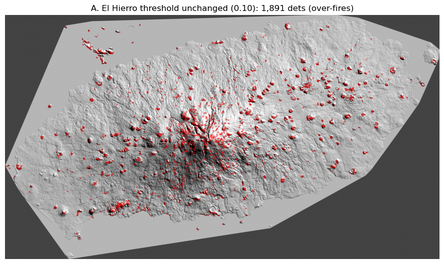

In [63]:
# panel 1 -> fig_zeroshot_1.png
fig, ax = plt.subplots(figsize=(9, 6))
det_un = cand_j[proba_j >= THR]
ax.imshow(ne_j, cmap="gray")
ax.scatter(det_un[:,1], det_un[:,0], s=2, c="red", alpha=0.4)
ax.axis("off"); ax.set_title(f"A. El Hierro threshold unchanged ({THR:.2f}): {n_unchanged:,} dets (over-fires)")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_zeroshot_1.png", dpi=120, bbox_inches="tight"); plt.show()

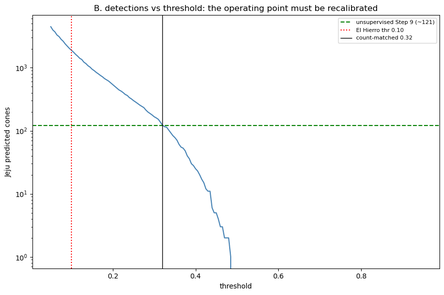

In [64]:
# panel 2 -> fig_zeroshot_2.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(grid, counts, color="steelblue"); ax.axhline(TGT, color="green", ls="--", label=f"unsupervised Step 9 (~{TGT})")
ax.axvline(THR, color="red", ls=":", label=f"El Hierro thr {THR:.2f}")
ax.axvline(thr_cal, color="k", ls="-", lw=1, label=f"count-matched {thr_cal:.2f}")
ax.set_xlabel("threshold"); ax.set_ylabel("Jeju predicted cones"); ax.set_yscale("log")
ax.set_title("B. detections vs threshold: the operating point must be recalibrated"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_zeroshot_2.png", dpi=120, bbox_inches="tight"); plt.show()

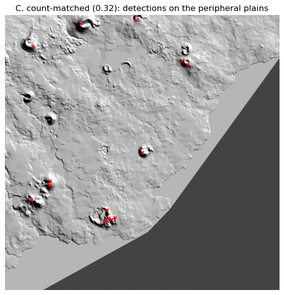

In [65]:
# panel 3 -> fig_zeroshot_3.png
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(ne_j, cmap="gray")
ax.scatter(det_cal[:,1], det_cal[:,0], s=20, c="red", marker="x")
ax.set_xlim(zx-half, zx+half); ax.set_ylim(zy+half, zy-half); ax.axis("off")
ax.set_title(f"C. count-matched ({thr_cal:.2f}): detections on the peripheral plains")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_zeroshot_3.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.**

The zero-shot transfer is the honest counterpart to Step 9: the El Hierro classifier, applied to Jeju with its threshold unchanged, **does not land on a plausible number** --- it over-fires (~1.9k detections, far more than the cone-like blobs the unsupervised Step 9 isolated on the same island).

**The operating point does not transfer across volcanoes**, because the predicted probabilities are calibrated to El Hierro's terrain, not Jeju's.

What *does* survive is the **ranking**: when the threshold is recalibrated so the detection count matches the unsupervised Step 9 estimate, the surviving detections fall on the peripheral plains where the cones actually are, away from the Hallasan massif --- the texture-plus-radial signature still orders cones above background on a new volcano.

**Honest limit.** With no Jeju labels we cannot pick that threshold from data, only borrow the unsupervised Step 9 count, so this stays qualitative.

Together the two Jeju steps give the full picture: the **representation generalises** (Step 9, the unsupervised cluster sits at the El Hierro cone-rim slope), but the **trained detector's calibration does not** (Step 9.5) --- which is exactly why, on a label-free island, the unsupervised route of Step 9 is the safer one.

---

## Step 10 — Cones along fissures (geological confirmation)

A closing, qualitative check tied to the brief on *linear geological patterns*: scoria cones are built on eruptive **fissures**, so the mapped cones should line up along them.

The El Hierro shapefile carries the fissures as a separate label (Id$=3$, azimuth in `Prj_Az`), so we overlay them on the cones and measure how close the cones fall to a fissure --- against a random-points null to show the alignment is real, not an artefact of the island being small.

In [66]:
# Step 10 - cones align along fissures (El Hierro, qualitative) -- RUNNABLE
# reuses gt (setup, all Ids), cen (crater centroids), valid, transform_h, hs_ne, FIG_DIR.
from rasterio.transform import xy as rc_to_xy
from shapely.geometry import Point
from shapely.ops import unary_union

fiss = gt[gt["Id"] == 3].reset_index(drop=True)                  # fissures (eruptive vents)
flines = [g for g in fiss.geometry if g is not None and g.length > 0]
fu = unary_union(flines)                                          # all fissure lines as one geometry

# 1) cone-to-nearest-fissure distance, vs a random-points null on land
d_cone = np.array([Point(x, y).distance(fu) for x, y in cen])
rng = np.random.default_rng(0)
ys, xs = np.where(valid); pick = rng.choice(len(ys), 3000, replace=False)
rxy = np.array([rc_to_xy(transform_h, int(ys[i]), int(xs[i])) for i in pick])
d_rand = np.array([Point(px, py).distance(fu) for px, py in rxy])
for thr in (250, 500):
    print(f"cones within {thr} m of a fissure : {100*(d_cone<thr).mean():.0f}%   (random points: {100*(d_rand<thr).mean():.0f}%)")
print(f"median distance to a fissure       : cones {np.median(d_cone):.0f} m   vs random {np.median(d_rand):.0f} m")
print(f"fissure swarm: {len(flines)} segments, {sum(g.length for g in flines)/1000:.0f} km total")

# 2) figure: A) cones on fissures  B) distance vs null  C) fissure azimuth rose
az = np.array([float(v) % 180 for v in fiss["Prj_Az"] if v is not None])

cones within 250 m of a fissure : 91%   (random points: 11%)
cones within 500 m of a fissure : 95%   (random points: 26%)
median distance to a fissure       : cones 7 m   vs random 1046 m
fissure swarm: 171 segments, 53 km total


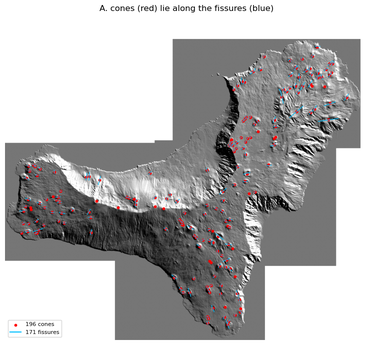

In [67]:
# panel 1 -> fig_fissures_1.png
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(hs_ne, cmap="gray")
for g in flines:
    rr, cc = rowcol(transform_h, *g.xy)
    ax.plot(cc, rr, "-", color="deepskyblue", lw=1.0, alpha=0.9)
gpix = np.array([rowcol(transform_h, x, y) for x, y in cen])
ax.scatter(gpix[:, 1], gpix[:, 0], s=10, c="red", label=f"{len(cen)} cones")
ax.plot([], [], "-", color="deepskyblue", label=f"{len(flines)} fissures")
ax.axis("off"); ax.legend(loc="lower left", fontsize=8)
ax.set_title("A. cones (red) lie along the fissures (blue)")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_fissures_1.png", dpi=120, bbox_inches="tight"); plt.show()

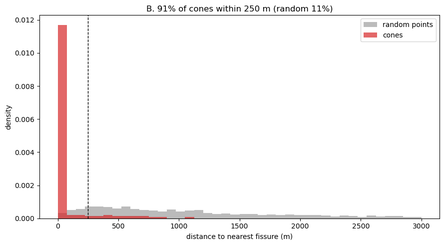

In [68]:
# panel 2 -> fig_fissures_2.png
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(d_rand, bins=40, range=(0, 3000), density=True, color="#bbbbbb", label="random points")
ax.hist(d_cone, bins=40, range=(0, 3000), density=True, color="#d62728", alpha=0.7, label="cones")
ax.axvline(250, color="k", ls="--", lw=1)
ax.set_xlabel("distance to nearest fissure (m)"); ax.set_ylabel("density")
ax.set_title(f"B. {100*(d_cone<250).mean():.0f}% of cones within 250 m (random {100*(d_rand<250).mean():.0f}%)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_fissures_2.png", dpi=120, bbox_inches="tight"); plt.show()

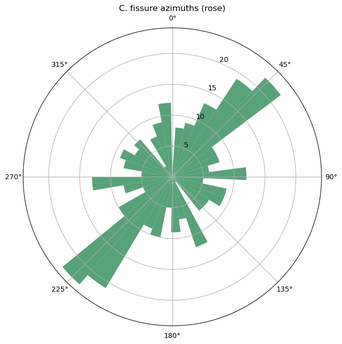

In [69]:
# panel 3 -> fig_fissures_3.png
fig = plt.figure(figsize=(7, 7)); ax = fig.add_subplot(111, projection="polar")
th = np.deg2rad(np.concatenate([az, az + 180]))                  # lines have no direction -> symmetric rose
ax.hist(th, bins=36, color="seagreen", alpha=0.8)
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_title("C. fissure azimuths (rose)")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_fissures_3.png", dpi=120, bbox_inches="tight"); plt.show()

**What we see.**

The cones do not sit randomly on the island: **~91 % lie within 250 m of a fissure, against ~11 % for random points**, and their median distance to a fissure is only a few metres --- the cones are built essentially *on* the eruptive lines.

The map makes the linear pattern obvious, and the azimuth rose shows the fissures share a preferred orientation (a NE–SW-leaning swarm), the tectonic fabric the cones follow.

This is a geological sanity check, not part of the detector --- but it confirms that what the pipeline detects are genuine vent-aligned constructional cones, closing the project on the *linear geological patterns* asked for in the brief.